# Call Center Dataset Analysis
This notebook aims to clean, explore, and analyze a call center dataset containing 5,000 call records. The goal is to uncover relationships between different features such as customer language choices, interactive menu selections, account validity, outstanding balances, and call handling metrics.

### Key Terminology Clarifications:
* **IVR (Interactive Voice Response):** The automated voice menu system that callers interact with before reaching an agent.
* **IVRPosition:** The specific step or stage within the IVR system where the caller was positioned (or where they hung up).
* **MainOption & SubOption:** The numerical or textual choices selected by the customer in the IVR menu layout.
* **SelectedQueue:** The specific department or routing line the caller was assigned to based on their choices.
* **EnteredQueue & IsAnswered:** Status flags indicating whether the call successfully reached the queue line and whether a human agent answered.

## Call Center Dataset Data Dictionary & Feature Documentation

This document provides a comprehensive breakdown of the variables and features captured within the call center dataset. The features are categorized into logical operational groups to assist in data cleaning, exploratory data analysis, and behavioral insights modeling.

---

### 1. Call & System Metadata
These fields record the base technical logs captured automatically by the telecom system upon call arrival.

* **`CALL_TIME`**: The exact date and timestamp when the customer's call entered the system.
* **`lang`**: The language preferred or selected by the caller at the beginning of the IVR interaction (e.g., `S` for Sinhala, `T` for Tamil, `E` for English, typical for telecom operators like Sri Lanka Telecom).
* **`IVRPosition`**: A specific system code indicating the last node, branch, or stage the customer reached within the interactive voice menu map before being routed or hanging up.

---

### 2. IVR Menu Selections
These variables capture user interactions with the automated Interactive Voice Response (IVR) keypad menus.

* **`mainOption`**: The primary menu option (numerical digit) selected by the caller on their phone keypad during the main IVR greeting.
* **`subOption`**: The specific sub-category or service line selected under the main option (e.g., `broadband`, `peotv` for IPTV services, `voice` for fixed/mobile lines, `extragb`, or `addon`).

---

### 3. Account & Service Status Flags
These attributes are retrieved dynamically from the Customer Relationship Management (CRM) and billing databases when the caller's account identifier is recognized.

* **`validAccount`**: A boolean value (`True`/`False`) indicating whether the system recognized the customer identifier or phone number as an active, legitimate account.
* **`outstanding`**: The current unpaid balance or financial dues on the customer's account. Negative values represent an overpayment or credit balance.
* **`existingFault`**: Indicates (`YES` or empty) if there is already an open, unresolved technical issue or complaint ticket logged for this customer's service.
* **`suspendedAsset`**: Indicates (`YES` or empty) whether the customer's connection or a service asset has been temporarily deactivated or suspended (often due to outstanding bills or contractual requests).
* **`dataLimitExceed`**: Indicates (`YES` or empty) if the customer has exhausted the high-speed data quota included in their primary internet bundle.
* **`extraGBAdded`**: Indicates (`YES` or empty) whether the customer has successfully purchased or activated an extra data top-up bundle.

---

### 4. Queue & Agent Routing Details
These flags monitor the customer's transition from automated menus to human-assisted queues.

* **`selectedQueue`**: The specific agent routing pool or department queue assigned to handle the call based on the user's IVR inputs (e.g., `S1`, `S41`).
* **`enteredQueue`**: Indicates (`YES` or empty) whether the caller successfully moved past the automated menu and entered a live hold queue waiting for a human agent.
* **`isAnswered`**: Indicates (`YES` or empty) if the call was successfully accepted and answered by a live customer service agent.

---

### 5. Call Duration Performance Metrics
These variables capture operational efficiency and key performance indicators (KPIs) associated with call duration, measured in seconds.

* **`queue_time`**: The time (in seconds) the customer spent waiting in the queue after choosing to speak with an agent until an agent responded.
* **`talk_time`**: The active duration (in seconds) of the conversation between the agent and the customer.
* **`total_time`**: The entire lifecycle duration of the call (in seconds). This encompasses the IVR automated menu navigation time, the `queue_time`, and the `talk_time`. 

> **Operational Formula:**
> The duration spent navigating the automated IVR menus is implicitly calculated using the following relationship:
> $$\text{IVR Menu Time} = \text{total\_time} - \text{queue\_time} - \text{talk\_time}$$

In [1]:
# Libraries
import pandas as pd


In [2]:
# Load the dataset
file_path = r"C:\Users\Mihiliya Jayasiri\Downloads\5000.csv"
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
df.head()

,CALL_TIME,lang,mainOption,subOption,IVRPosition,existingFault,suspendedAsset,dataLimitExceed,extraGBAdded,validAccount,...,queue_time,talk_time,total_time,Column1,queue+talk,time_less_100,time_less_200,time_less_300,time_less_500,time_greater_500
0,5/13/2026 23:59,S,14.0,NaN,S7,NaN,NaN,NaN,NaN,True,...,273,85,447,NaN,358,False,False,False,True,False
1,5/13/2026 23:59,S,4.0,extragb,S4112,NaN,NaN,NaN,NaN,True,...,0,0,60,NaN,0,True,True,True,True,False
2,5/13/2026 23:59,S,1.0,NaN,S1,NaN,NaN,NaN,NaN,True,...,225,172,480,NaN,397,False,False,False,True,False
3,5/13/2026 23:59,S,1.0,NaN,SLty1,NaN,NaN,NaN,NaN,False,...,0,0,129,NaN,0,False,True,True,True,False
4,5/13/2026 23:59,S,NaN,NaN,S,NaN,NaN,NaN,NaN,False,...,0,0,74,NaN,0,True,True,True,True,False


## Section 1: Initial Data Exploration
In this section, we examine the dataset's shape, basic properties, data types, and missing values across all columns to evaluate data quality and completeness.

In [3]:
# High-level structural overview
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (5000, 24)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CALL_TIME         5000 non-null   object 
 1   lang              4604 non-null   object 
 2   mainOption        3563 non-null   float64
 3   subOption         2400 non-null   object 
 4   IVRPosition       4604 non-null   object 
 5   existingFault     131 non-null    object 
 6   suspendedAsset    645 non-null    object 
 7   dataLimitExceed   51 non-null     object 
 8   extraGBAdded      279 non-null    object 
 9   validAccount      4994 non-null   object 
 10  outstanding       3388 non-null   float64
 11  selectedQueue     3572 non-null   object 
 12  enteredQueue      2713 non-null   object 
 13  isAnswered        787 non-null    object 
 14  queue_time        5000 non-null   int64  
 15  talk_time         5000 non-null   int64  
 16  total_time        5000 non-null   int64  


In [5]:
df.describe()

,mainOption,outstanding,queue_time,talk_time,total_time,Column1,queue+talk
count,3563.000000,3.388000e+03,5000.000000,5000.000000,5000.000000,0.0,5000.000000
mean,3.636542,1.118705e+04,117.094600,19.227200,328.673800,NaN,136.321800
std,3.571218,2.145526e+05,290.487126,62.461667,367.628622,NaN,334.143754
min,1.000000,-1.250000e+04,0.000000,0.000000,0.000000,NaN,0.000000
25%,2.000000,3.349000e+01,0.000000,0.000000,39.000000,NaN,0.000000
50%,2.000000,3.486560e+03,0.000000,0.000000,157.000000,NaN,0.000000
75%,4.000000,6.374560e+03,0.000000,0.000000,519.000000,NaN,0.000000
max,14.000000,1.156483e+07,1655.000000,868.000000,2296.000000,NaN,1688.000000


## Section 2: Examining Unique Values per Feature
Understanding the distinct categories within each text or discrete feature helps pinpoint the scope of customer interactions and data patterns.

In [6]:
# Display unique values for all features to see their domain ranges
for col in df.columns:
    print(f"{col}: {df[col].dropna().unique()[:5]} (Total unique: {df[col].nunique()})")

CALL_TIME: ['5/13/2026 23:59' '5/13/2026 23:58' '5/13/2026 23:57' '5/13/2026 23:56'
 '5/13/2026 23:55'] (Total unique: 136)
lang: ['S' 'T' 'E'] (Total unique: 3)
mainOption: [14.  4.  1.  2.  3.] (Total unique: 8)
subOption: ['extragb' 'peotv' 'voice' 'broadband' 'addon'] (Total unique: 11)
IVRPosition: ['S7' 'S4112' 'S1' 'SLty1' 'S'] (Total unique: 99)
existingFault: ['YES'] (Total unique: 1)
suspendedAsset: ['YES'] (Total unique: 1)
dataLimitExceed: ['YES'] (Total unique: 1)
extraGBAdded: ['YES'] (Total unique: 1)
validAccount: [True False] (Total unique: 2)
outstanding: [6467.85 2979.45  -84.53 -435.55 8515.52] (Total unique: 2234)
selectedQueue: ['S7' 'S41' 'S1' 'S2' 'S3'] (Total unique: 26)
enteredQueue: ['YES'] (Total unique: 1)
isAnswered: ['YES'] (Total unique: 1)
queue_time: [273   0 225 291 229] (Total unique: 452)
talk_time: [ 85   0 172  43 101] (Total unique: 264)
total_time: [447  60 480 129  74] (Total unique: 1172)
Column1: [] (Total unique: 0)
queue+talk: [358   0 397 

In [7]:
# Deep dive into specific key categorical columns
for col in ["lang", "mainOption", "subOption"]:
    print(f"{col}: {df[col].dropna().unique()[:12]} (Total unique: {df[col].nunique()})")

lang: ['S' 'T' 'E'] (Total unique: 3)
mainOption: [14.  4.  1.  2.  3.  6. 11.  5.] (Total unique: 8)
subOption: ['extragb' 'peotv' 'voice' 'broadband' 'addon' '1' 'other' 'residential'
 'timeout' 'organizational' 'tele_rainbow'] (Total unique: 11)


### Questions???
1. What are the 8 mainOptions means in text?
2. What are the different types of IVR positions (specially ones that have i's and Lty meaning)?
3. What is the relationship between IVRPostion and selectedQueue?

## Section 3: Data Cleaning & Preprocessing

### 1. Standardizing Binary Flags
Features like `existingFault`, `suspendedAsset`, `dataLimitExceed`, `extraGBAdded`, `enteredQueue`, and `isAnswered` only explicitly store `"YES"`. For these columns, the missing values (`NaN`) inherently denote the absence of that condition, meaning they can safely be treated as `"NO"`.

In [8]:
# Fill missing categorical values with 'NO' for binary status indicators
only_yes_cols = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded", "enteredQueue", "isAnswered"]
df[only_yes_cols] = df[only_yes_cols].fillna("NO")

# Verify the changes
df.head()

,CALL_TIME,lang,mainOption,subOption,IVRPosition,existingFault,suspendedAsset,dataLimitExceed,extraGBAdded,validAccount,...,queue_time,talk_time,total_time,Column1,queue+talk,time_less_100,time_less_200,time_less_300,time_less_500,time_greater_500
0,5/13/2026 23:59,S,14.0,NaN,S7,NO,NO,NO,NO,True,...,273,85,447,NaN,358,False,False,False,True,False
1,5/13/2026 23:59,S,4.0,extragb,S4112,NO,NO,NO,NO,True,...,0,0,60,NaN,0,True,True,True,True,False
2,5/13/2026 23:59,S,1.0,NaN,S1,NO,NO,NO,NO,True,...,225,172,480,NaN,397,False,False,False,True,False
3,5/13/2026 23:59,S,1.0,NaN,SLty1,NO,NO,NO,NO,False,...,0,0,129,NaN,0,False,True,True,True,False
4,5/13/2026 23:59,S,NaN,NaN,S,NO,NO,NO,NO,False,...,0,0,74,NaN,0,True,True,True,True,False


In [9]:
# Recheck column fill counts after mapping binary flags
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CALL_TIME         5000 non-null   object 
 1   lang              4604 non-null   object 
 2   mainOption        3563 non-null   float64
 3   subOption         2400 non-null   object 
 4   IVRPosition       4604 non-null   object 
 5   existingFault     5000 non-null   object 
 6   suspendedAsset    5000 non-null   object 
 7   dataLimitExceed   5000 non-null   object 
 8   extraGBAdded      5000 non-null   object 
 9   validAccount      4994 non-null   object 
 10  outstanding       3388 non-null   float64
 11  selectedQueue     3572 non-null   object 
 12  enteredQueue      5000 non-null   object 
 13  isAnswered        5000 non-null   object 
 14  queue_time        5000 non-null   int64  
 15  talk_time         5000 non-null   int64  
 16  total_time        5000 non-null   int64  


### 2. Identifying and Removing Dropped Calls
When both `lang` (Language choice) and `IVRPosition` are missing, it indicates a customer who hung up immediately after dialing in without interacting with the system. We will verify if these are extremely brief calls and remove them from our core behavioral analysis.

In [10]:
# Filter the DataFrame to rows where 'lang' is null
lang_null_df = df[df['lang'].isnull()]

# Verify if 'IVRPosition' is also always missing when 'lang' is missing
is_ivr_always_null = lang_null_df['IVRPosition'].isnull().all()

print(f"Total rows where 'lang' is null: {len(lang_null_df)}")
print(f"Is 'IVRPosition' also null for all these rows? {is_ivr_always_null}")

Total rows where 'lang' is null: 396
Is 'IVRPosition' also null for all these rows? True


In [11]:
# Check if these early dropped calls are shorter than 60 seconds
null_condition = df['lang'].isnull() & df['IVRPosition'].isnull()
filtered_df = df[null_condition]

all_less_than_60 = (filtered_df['total_time'] < 60).all()

print(f"Total rows where both 'lang' and 'IVRPosition' are null: {len(filtered_df)}")
print(f"Are all of these calls shorter than 60 seconds? {all_less_than_60}")

print("\nSummary statistics of total_time (in seconds) for these dropped rows:")
print(filtered_df['total_time'].describe())

Total rows where both 'lang' and 'IVRPosition' are null: 396
Are all of these calls shorter than 60 seconds? True

Summary statistics of total_time (in seconds) for these dropped rows:
count    396.000000
mean       7.863636
std        4.388315
min        0.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       21.000000
Name: total_time, dtype: float64


In [12]:
# Remove these early-dropped rows from the main DataFrame in-place
df.dropna(subset=['lang'], inplace=True)
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (4604, 24)


In [13]:
# Verify dataset state after removal
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4604 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CALL_TIME         4604 non-null   object 
 1   lang              4604 non-null   object 
 2   mainOption        3563 non-null   float64
 3   subOption         2400 non-null   object 
 4   IVRPosition       4604 non-null   object 
 5   existingFault     4604 non-null   object 
 6   suspendedAsset    4604 non-null   object 
 7   dataLimitExceed   4604 non-null   object 
 8   extraGBAdded      4604 non-null   object 
 9   validAccount      4598 non-null   object 
 10  outstanding       3388 non-null   float64
 11  selectedQueue     3571 non-null   object 
 12  enteredQueue      4604 non-null   object 
 13  isAnswered        4604 non-null   object 
 14  queue_time        4604 non-null   int64  
 15  talk_time         4604 non-null   int64  
 16  total_time        4604 non-null   int64  
 17  

## Section 4: Analyzing Feature Relationships


### 1. Main Menu Options vs. Sub-Options
Let's discover the underlying operational hierarchy of the IVR system by tracking which `subOption` selections belong under specific `mainOption` inputs.

In [14]:
# Group by mainOption and extract lists of associated unique subOptions
sub_options_per_main = (
    df.groupby('mainOption')['subOption']
    .unique()
    .apply(lambda x: [val for val in x if pd.notnull(val)])
)

# Display the nested routing rules
for main_opt, sub_opts in sub_options_per_main.items():
    print(f"Main Option {main_opt}: {sub_opts if sub_opts else 'No sub-options available'}")

Main Option 1.0: No sub-options available
Main Option 2.0: ['peotv', 'voice', 'broadband', 'other']
Main Option 3.0: No sub-options available
Main Option 4.0: ['extragb', 'addon']
Main Option 5.0: ['residential', 'timeout', 'organizational', 'tele_rainbow']
Main Option 6.0: ['1']
Main Option 11.0: No sub-options available
Main Option 14.0: No sub-options available


### Questions???

1. What does each main option mean?
2. Are there  any other suboptions that are not available here?
3. What is meant by sub option 1 in main option 6?
4. What are the meanings of sub options in 5th main option?

### 1.1 Finding: Behavior of Null Main Menu Choices
When a customer does not make a choice on the main IVR menu (`mainOption` is missing), they cannot access any sub-menus, and their status flag signals stay clear.

In [15]:
# Filter rows where mainOption is missing
null_main_df = df[df['mainOption'].isnull()]
total_rows = len(null_main_df)

# Confirm subOption is also null
is_sub_always_null = null_main_df['subOption'].isnull().all()

# Check account metrics status columns
status_cols = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]
are_flags_no_or_null = all(
    null_main_df[col].isnull().all() or (null_main_df[col] == "NO").all() 
    for col in status_cols
)

print(f"Total rows where 'mainOption' is null: {total_rows}")
print(f"1. Is 'subOption' definitely null? {is_sub_always_null}")
print(f"2. Are all status flags ('existingFault', 'suspendedAsset', etc.) 'NO'? {are_flags_no_or_null}")

Total rows where 'mainOption' is null: 1041
1. Is 'subOption' definitely null? True
2. Are all status flags ('existingFault', 'suspendedAsset', etc.) 'NO'? True


Similarly, for any call record where a `subOption` is absent, the account status metrics (`existingFault`, `suspendedAsset`, `dataLimitExceed`, `extraGBAdded`.) uniformly default to `"NO"`.

In [16]:
# Filter rows where subOption is null
null_sub_df = df[df['subOption'].isnull()]
total_null_sub_rows = len(null_sub_df)

# Check status columns consistency
are_all_flags_no_or_null = all(
    null_sub_df[col].isnull().all() or (null_sub_df[col] == "NO").all()
    for col in status_cols
)

print(f"Total rows where 'subOption' is null: {total_null_sub_rows}")
print(f"Is it TRUE that all account flags are empty/NO when subOption is null? {are_all_flags_no_or_null}")

print("\nDetailed column breakdown:")
for col in status_cols:
    non_null_count = null_sub_df[col].notnull().sum()
    print(f" - Column '{col}' contains {non_null_count} active entries.")

Total rows where 'subOption' is null: 2204
Is it TRUE that all account flags are empty/NO when subOption is null? True

Detailed column breakdown:
 - Column 'existingFault' contains 2204 active entries.
 - Column 'suspendedAsset' contains 2204 active entries.
 - Column 'dataLimitExceed' contains 2204 active entries.
 - Column 'extraGBAdded' contains 2204 active entries.


Also account metrics `existingFault`, `suspendedAsset` and `dataLimitExceed` have no relationship, if one have `"YES"` other don't. As of `dataLimitExceed` as `"YES"`,it has records with `extraGBAdded` as `"YES"`.

### 2. Deep Dive: IVR Position Menu Nodes
Let's see what unique system steps (`IVRPosition`) are triggered across the different core menu paths chosen by callers.

In [17]:
# Group by mainOption (retaining missing choices as a distinct group) to log active IVR positions
ivr_per_main = (
    df.groupby('mainOption', dropna=False)['IVRPosition']
    .unique()
    .apply(lambda x: [val for val in x if pd.notnull(val)])
)

print("--- IVR Positions mapped per Main Menu Choice ---")
for main_opt, ivr_positions in ivr_per_main.items():
    label = "Null / Missing Option" if pd.isnull(main_opt) else f"Main Option {main_opt}"
    print(f"\n{label} (Total unique positions: {len(ivr_positions)}):")
    print(sorted(list(ivr_positions)))

--- IVR Positions mapped per Main Menu Choice ---

Main Option 1.0 (Total unique positions: 9):
['ELty1', 'MOBITEL_ELty1', 'MOBITEL_S1', 'MOBITEL_SLty1', 'MOBITEL_T1', 'MOBITEL_TLty1', 'S1', 'SLty1', 'TLty1']

Main Option 2.0 (Total unique positions: 34):
['E21', 'E22', 'E221', 'E222', 'E23', 'E24', 'E2t', 'MOBITEL_E21', 'MOBITEL_S21', 'MOBITEL_S211', 'MOBITEL_S22', 'MOBITEL_S221', 'MOBITEL_S23', 'MOBITEL_S24', 'MOBITEL_S2t', 'MOBITEL_T2', 'S2', 'S21', 'S211', 'S22', 'S221', 'S222', 'S22i', 'S23', 'S24', 'S2i', 'S2t', 'T21', 'T211', 'T22', 'T221', 'T222', 'T23', 'T231']

Main Option 3.0 (Total unique positions: 5):
['E3', 'MOBITEL_E3', 'MOBITEL_S3', 'S3', 'T3']

Main Option 4.0 (Total unique positions: 34):
['E411', 'E4111', 'E4112', 'E41121', 'E412', 'E41211', 'E41t', 'MOBITEL_E4112', 'MOBITEL_S41', 'MOBITEL_S4111', 'MOBITEL_S4112', 'MOBITEL_S41122', 'MOBITEL_S41t', 'S41', 'S411', 'S4111', 'S411121', 'S4112', 'S41121', 'S41122', 'S411223', 'S4113', 'S41131', 'S412', 'S41211', 'S41213'

In [18]:
# Group by subOption to trace position mappings
ivr_per_sub = (
    df.groupby('subOption', dropna=False)['IVRPosition']
    .unique()
    .apply(lambda x: [val for val in x if pd.notnull(val)])
)

print("--- IVR Positions mapped per Sub-Option Category ---")
for sub_opt, ivr_positions in ivr_per_sub.items():
    label = "Null / Missing Sub-Option" if pd.isnull(sub_opt) else f"Sub-Option '{sub_opt}'"
    print(f"\n{label} (Total unique positions: {len(ivr_positions)}):")
    print(sorted(list(ivr_positions)))

--- IVR Positions mapped per Sub-Option Category ---

Sub-Option '1' (Total unique positions: 1):
['S1']

Sub-Option 'addon' (Total unique positions: 6):
['E412', 'E41211', 'S412', 'S41211', 'S41213', 'S4122']

Sub-Option 'broadband' (Total unique positions: 12):
['E22', 'E221', 'E222', 'MOBITEL_S22', 'MOBITEL_S221', 'S22', 'S221', 'S222', 'S22i', 'T22', 'T221', 'T222']

Sub-Option 'extragb' (Total unique positions: 26):
['E411', 'E4111', 'E4112', 'E41121', 'E41t', 'MOBITEL_E4112', 'MOBITEL_S4111', 'MOBITEL_S4112', 'MOBITEL_S41122', 'MOBITEL_S41t', 'S411', 'S4111', 'S411121', 'S4112', 'S41121', 'S41122', 'S411223', 'S4113', 'S41131', 'S41i', 'S41t', 'T411', 'T4111', 'T4112', 'T4113', 'T41t']

Sub-Option 'organizational' (Total unique positions: 1):
['S51']

Sub-Option 'other' (Total unique positions: 7):
['E24', 'E2t', 'MOBITEL_S24', 'MOBITEL_S2t', 'S24', 'S2i', 'S2t']

Sub-Option 'peotv' (Total unique positions: 8):
['E21', 'MOBITEL_E21', 'MOBITEL_S21', 'MOBITEL_S211', 'S21', 'S211', 

### 2.2 Finding: Calls Hanging Up on Root Language Screen
When **both** choices are completely missing, the customer only reaches the base language routing menu nodes (`'S'`, `'T'`, `'E'`, or their mobile counterparts).

In [19]:
# Filter rows where both options are null
null_both_df = df[df['mainOption'].isnull() & df['subOption'].isnull()]
unique_positions = null_both_df['IVRPosition'].unique()

print(f"Total rows where both options are null: {len(null_both_df)}")
print(f"\nUnique IVRPosition values reached:\n{unique_positions}")

print("\nFrequency breakdown of these root positions:")
print(null_both_df['IVRPosition'].value_counts(dropna=False))

Total rows where both options are null: 1041

Unique IVRPosition values reached:
['S' 'T' 'MOBITEL_S' 'E' 'MOBITEL_E' 'MOBITEL_T']

Frequency breakdown of these root positions:
IVRPosition
S            920
T             54
MOBITEL_S     31
E             29
MOBITEL_E      6
MOBITEL_T      1
Name: count, dtype: int64


### 3. Valid Account Mappings vs. Outstanding Balances & Queues
Here, we check how account validity relates to financial balances and routing rules.

In [20]:
# Filter rows where validAccount is False
false_account_df = df[df['validAccount'].astype(str).str.upper() == 'FALSE']

# Check if outstanding balance is always missing
is_outstanding_always_null = false_account_df['outstanding'].isnull().all()

print(f"Total rows where 'validAccount' is False: {len(false_account_df)}")
print(f"Is 'outstanding' balance always null for these rows? {is_outstanding_always_null}")

Total rows where 'validAccount' is False: 1210
Is 'outstanding' balance always null for these rows? True


### 3.1 Finding: Behavior of Null Account Validity
When `validAccount` is missing entirely, it is highly isolated: it only occurs under `mainOption` 6.0 and specifically routes callers directly to an emergency/specialized queue named `"ECS"`.

In [21]:
# Filter rows where validAccount is null
null_account_df = df[df['validAccount'].isnull()]
total_null_account_rows = len(null_account_df)

is_always_main_6 = (null_account_df['mainOption'] == 6.0).all()
is_always_ecs = (null_account_df['selectedQueue'] == "ECS").all()

print(f"Total rows where 'validAccount' is null: {total_null_account_rows}")
print(f"1. Do they all belong to mainOption 6? {is_always_main_6}")
print(f"2. Is the selectedQueue always 'ECS'? {is_always_ecs}")

Total rows where 'validAccount' is null: 6
1. Do they all belong to mainOption 6? True
2. Is the selectedQueue always 'ECS'? True


### 3.2 Finding: Restrictions for False Accounts
When `validAccount` is explicitly flagged as `False`, callers are strictly restricted. They only have access to sub-options `'other'` and `'extragb'`, and all flags are `"NO"`.

In [22]:
# Gather unique sub-options for False accounts
actual_sub_options = [opt for opt in false_account_df['subOption'].unique() if pd.notnull(opt)]
expected_sub_options = ['other', 'extragb']
is_sub_option_matching = set(actual_sub_options) == set(expected_sub_options)

print(f"1. Are the only active sub-options 'other' and 'extragb'? {is_sub_option_matching} (Found: {actual_sub_options})")

1. Are the only active sub-options 'other' and 'extragb'? True (Found: ['extragb', 'other'])


### Questions???

1. What is ECS? Why does it only come under main option 6?
2. What is included in other suboption?

### 4. Exploring SelectedQueue Routing Rules
Finally, we analyze rows with missing `selectedQueue` data to verify if these indicate calls where the user abandoned the system at the entry menu phase.

In [23]:
# Filter rows where selectedQueue is missing
null_queue_df = df[df['selectedQueue'].isnull()]
total_null_queue_rows = len(null_queue_df)

print(f"Total rows where 'selectedQueue' is null: {total_null_queue_rows}")

Total rows where 'selectedQueue' is null: 1033


If a call leaves the system before being assigned to a `selectedQueue`, it never queues up or gets answered, resulting in exactly `0` wait or talk times.

In [24]:
# Check handling and queue metrics
is_entered_queue_no = (null_queue_df['enteredQueue'] == "NO").all()
is_answered_no = (null_queue_df['isAnswered'] == "NO").all()
is_queue_time_zero = (null_queue_df['queue_time'] == 0).all()
is_talk_time_zero = (null_queue_df['talk_time'] == 0).all()

print(f"1. Are 'enteredQueue' values all 'NO'? {is_entered_queue_no}")
print(f"2. Are 'isAnswered' values all 'NO'? {is_answered_no}")
print(f"3. Are all 'queue_time' values exactly 0? {is_queue_time_zero}")
print(f"4. Are all 'talk_time' values exactly 0? {is_talk_time_zero}")

1. Are 'enteredQueue' values all 'NO'? True
2. Are 'isAnswered' values all 'NO'? True
3. Are all 'queue_time' values exactly 0? True
4. Are all 'talk_time' values exactly 0? True


In [25]:
# Confirm their position tree values match expected root nodes
unique_positions_null_queue = null_queue_df['IVRPosition'].unique()
expected_list = ['E', 'MOBITEL_E', 'MOBITEL_S', 'MOBITEL_T', 'S', 'T']
is_exactly_matching = set(unique_positions_null_queue) == set(expected_list)

print(f"Do the position values match the root language menus? {is_exactly_matching}")
print(f"IVRpositions found when selectedQueue is null: {unique_positions_null_queue}")

Do the position values match the root language menus? True
IVRpositions found when selectedQueue is null: ['S' 'T' 'MOBITEL_S' 'E' 'MOBITEL_E' 'MOBITEL_T']


### 5. Final Mappings Validation
A final calculation check shows a perfect breakdown split between outstanding accounts.

In [26]:
# Count condition where validAccount is False OR Null
condition = (df['validAccount'].astype(str).str.upper() == 'FALSE') | df['validAccount'].isnull()
subset_df = df[condition]

print(f"Total rows where 'validAccount' is False or Null: {len(subset_df)}")
print(f"Number of null values in 'outstanding' for these rows: {subset_df['outstanding'].isnull().sum()}")

Total rows where 'validAccount' is False or Null: 1216
Number of null values in 'outstanding' for these rows: 1216


### Questions???

1. Is this dataset is of 1212 dials?
2. Is the reason for validAccounts to be false and null because those calls were from non sltm numbers?

## New Column Recommendations


1. IVR Menu Time
2. Separate date and time

# Changing Date and Time to separate columns

In [27]:
# 1. Convert the CALL_TIME column to a datetime format
df['CALL_TIME'] = pd.to_datetime(df['CALL_TIME'])

# 2. Extract the date into a new column
df['CALL_DATE'] = df['CALL_TIME'].dt.date

# 3. Extract the time into a new column
df['CALL_TIME_ONLY'] = df['CALL_TIME'].dt.time

# Preview the changes
df[['CALL_TIME', 'CALL_DATE', 'CALL_TIME_ONLY']].head()

,CALL_TIME,CALL_DATE,CALL_TIME_ONLY
0,2026-05-13 23:59:00,2026-05-13,23:59:00
1,2026-05-13 23:59:00,2026-05-13,23:59:00
2,2026-05-13 23:59:00,2026-05-13,23:59:00
3,2026-05-13 23:59:00,2026-05-13,23:59:00
4,2026-05-13 23:59:00,2026-05-13,23:59:00


In [28]:
df.head()

,CALL_TIME,lang,mainOption,subOption,IVRPosition,existingFault,suspendedAsset,dataLimitExceed,extraGBAdded,validAccount,...,total_time,Column1,queue+talk,time_less_100,time_less_200,time_less_300,time_less_500,time_greater_500,CALL_DATE,CALL_TIME_ONLY
0,2026-05-13 23:59:00,S,14.0,NaN,S7,NO,NO,NO,NO,True,...,447,NaN,358,False,False,False,True,False,2026-05-13,23:59:00
1,2026-05-13 23:59:00,S,4.0,extragb,S4112,NO,NO,NO,NO,True,...,60,NaN,0,True,True,True,True,False,2026-05-13,23:59:00
2,2026-05-13 23:59:00,S,1.0,NaN,S1,NO,NO,NO,NO,True,...,480,NaN,397,False,False,False,True,False,2026-05-13,23:59:00
3,2026-05-13 23:59:00,S,1.0,NaN,SLty1,NO,NO,NO,NO,False,...,129,NaN,0,False,True,True,True,False,2026-05-13,23:59:00
4,2026-05-13 23:59:00,S,NaN,NaN,S,NO,NO,NO,NO,False,...,74,NaN,0,True,True,True,True,False,2026-05-13,23:59:00


In [29]:
# Replace both 14.0 and 11.0 with 7.0 in the mainOption column
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

Total calls received within 1 minute of 2026-05-13 23:58:00: 34


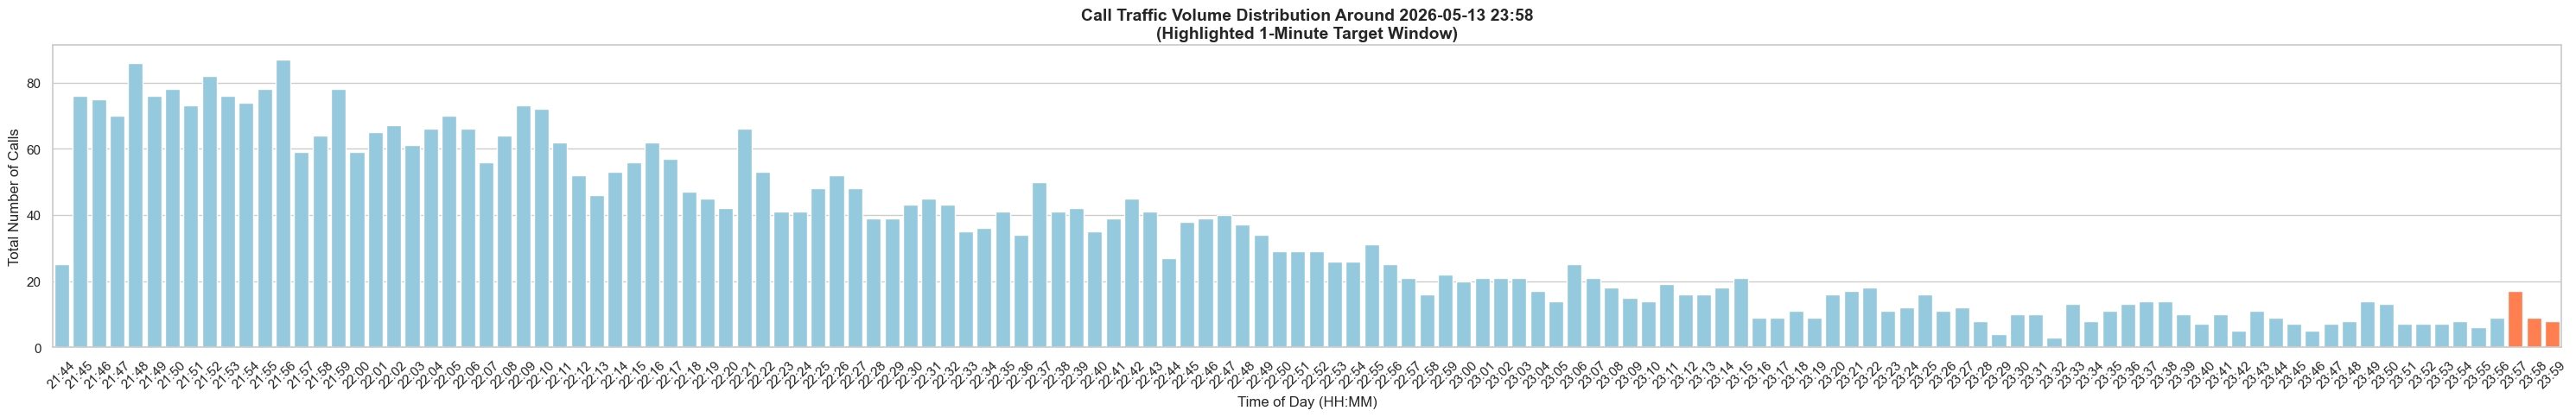

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure the CALL_TIME column is in a proper datetime format
df['CALL_TIME'] = pd.to_datetime(df['CALL_TIME'])

# 2. Define your chosen date and time string
# Change this to any timestamp you want to investigate
chosen_time_str = "2026-05-13 23:58:00" 
chosen_time = pd.to_datetime(chosen_time_str)

# 3. Define the 1-minute window boundary (+/- 1 minute from the chosen time)
start_window = chosen_time - pd.Timedelta(minutes=1)
end_window = chosen_time + pd.Timedelta(minutes=1)

# 4. Filter the dataframe to find calls within this window
calls_within_window = df[(df['CALL_TIME'] >= start_window) & (df['CALL_TIME'] <= end_window)]
print(f"Total calls received within 1 minute of {chosen_time_str}: {len(calls_within_window)}")

# --- SEABORN VISUALIZATION ---

# Define a 10-minute historical display window around your chosen time to provide context
plot_start = chosen_time - pd.Timedelta(minutes=14800)
plot_end = chosen_time + pd.Timedelta(minutes=14800)

# Filter data for the visual display timeline
df_plot = df[(df['CALL_TIME'] >= plot_start) & (df['CALL_TIME'] <= plot_end)].copy()

# Group by exact minute to calculate traffic density
df_counts = df_plot.groupby('CALL_TIME').size().reset_index(name='Call Count')
df_counts['Time_Label'] = df_counts['CALL_TIME'].dt.strftime('%H:%M')

# Set up the Seaborn chart style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(30, 5))

# Generate a bar plot of call volumes
ax = sns.barplot(data=df_counts, x='Time_Label', y='Call Count', color='skyblue')

# Automatically highlight the bars that fall inside your requested 1-minute window
for bar in ax.patches:
    x_coord = bar.get_x()
    idx = int(x_coord + 0.5)
    if idx < len(df_counts):
        bar_timestamp = df_counts.iloc[idx]['CALL_TIME']
        # If the bar falls within the 1-minute filter window, color it orange
        if start_window <= bar_timestamp <= end_window:
            bar.set_facecolor('coral')

# Adjust layout properties for readability
plt.title(f"Call Traffic Volume Distribution Around {chosen_time.strftime('%Y-%m-%d %H:%M')}\n(Highlighted 1-Minute Target Window)", fontsize=14, fontweight='bold')
plt.xlabel("Time of Day (HH:MM)", fontsize=12)
plt.ylabel("Total Number of Calls", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the visualization plot
plt.savefig('call_volumes_analysis.png', dpi=300)
plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 1. Ensure the dataset columns are formatted correctly
df['CALL_TIME'] = pd.to_datetime(df['CALL_TIME'])
df['Hour'] = df['CALL_TIME'].dt.hour
df['Minute'] = df['CALL_TIME'].dt.minute

# 2. Define the callback function that executes with each choice
def view_hour_analytics(chosen_hour):
    # Filter the primary dataframe for the selected hour block
    hour_df = df[df['Hour'] == chosen_hour]
    total_calls = len(hour_df)
    
    # Text Interface Header
    print(f"=========================================")
    print(f"OPERATIONAL METRICS FOR HOUR: {chosen_hour:02d}:00")
    print(f"=========================================")
    print(f"Total Calls Processed: {total_calls}\n")
    
    if total_calls == 0:
        print("No call records found during this time frame.")
        return
        
    # Quick Category Breakdowns
    print("Preferred Language Mix:")
    print(hour_df['lang'].value_counts().to_string())
    print("\nAgent Answer Status:")
    print(hour_df['isAnswered'].value_counts().to_string())
    
    # 3. Dynamic Seaborn Visualization Layout
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Chart A: Call Timeline Traffic Volatility 
    minute_counts = hour_df.groupby('Minute').size().reset_index(name='Call Count')
    # Reindex to ensure all 60 minutes of the hour are uniformly displayed
    minute_counts = minute_counts.set_index('Minute').reindex(range(60), fill_value=0).reset_index()
    
    sns.lineplot(ax=axes[0], data=minute_counts, x='Minute', y='Call Count', marker='o', color='RoyalBlue', linewidth=2)
    axes[0].set_title(f"Call Traffic Fluctuations (Within Hour {chosen_hour:02d}:00)", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Minute of the Hour", fontsize=10)
    axes[0].set_ylabel("Volume of Incoming Calls", fontsize=10)
    axes[0].set_xlim(0, 59)
    
    # Chart B: Destination Queue Load Split
    queue_counts = hour_df['selectedQueue'].value_counts().reset_index(name='Count')
    if not queue_counts.empty:
        sns.barplot(ax=axes[1], data=queue_counts, x='selectedQueue', y='Count', palette='flare', hue='selectedQueue', legend=True)
        axes[1].set_title("Routing Queue Distribution Density", fontsize=12, fontweight='bold')
        axes[1].set_xlabel("Target Department Queue", fontsize=10)
        axes[1].set_ylabel("Call Count Allocation", fontsize=10)
        axes[1].tick_params(axis='x', rotation=90)
    else:
        axes[1].text(0.5, 0.5, 'No Queue Allocation Found', ha='center', va='center', fontsize=12, color='gray')
        
    plt.tight_layout()
    plt.show()

# 4. Generate the Interactive Dropdown Controller UI Component
interact(
    view_hour_analytics, 
    chosen_hour=widgets.Dropdown(
        options=sorted(df['Hour'].unique()), 
        value=sorted(df['Hour'].unique())[0], # Defaults to the earliest active hour entry
        description='Choose Hour:',
        disabled=False,
    )
)

interactive(children=(Dropdown(description='Choose Hour:', options=(np.int32(21), np.int32(22), np.int32(23)),…

<function __main__.view_hour_analytics(chosen_hour)>

# Mainoption and Suboption

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import numpy as np

# 1. Clean duration inputs to ensure absolute integer validation
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Build sorted dropdown select list options including Null structures
unique_options = df['mainOption'].dropna().unique()
sorted_numeric_options = sorted([float(opt) for opt in unique_options])

dropdown_options = [str(opt) for opt in sorted_numeric_options]
dropdown_options.append('Null / Missing')

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# Helper function to categorize and bin durations with strict LaTeX math formatting
def compute_interval_slices(time_series):
    count_0 = len(time_series[time_series == 0])
    count_300 = len(time_series[(time_series > 0) & (time_series <= 300)])
    count_600 = len(time_series[(time_series > 300) & (time_series <= 600)])
    count_above = len(time_series[time_series > 600])
    
    raw_counts = [count_0, count_300, count_600, count_above]
    raw_labels = [
        '0s (0m)', 
        '$> 0$s and $\\leq 300$s ($\\leq 5$m)', 
        '$> 300$s and $\\leq 600$s ($> 5$m to $\\leq 10$m)', 
        '$> 600$s ($> 10$m)'
    ]
    
    # Exclude empty categories with zero counts to keep the pie charts clean
    clean_pairs = [(count, lbl) for count, lbl in zip(raw_counts, raw_labels) if count > 0]
    
    if not clean_pairs:
        return [], []
    
    counts, labels = zip(*clean_pairs)
    return list(counts), list(labels)

# Helper function to cleanly position external callout labels with pointing arrows
def draw_callout_labels(ax, wedges, counts):
    total = sum(counts)
    pct_labels = [f"{(c / total) * 100:.1f}%" for c in counts]
    
    ann_data = []
    for i, p in enumerate(wedges):
        # Calculate the center angle of the current slice safely
        ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        
        # Target coordinate positions outside the perimeter ring (Radius: 1.35)
        tx = 1.35 * x
        ty = 1.35 * y
        ann_data.append([i, x, y, tx, ty, ang])
        
    # Sort counter-clockwise by angle to ensure sequential evaluation
    ann_data.sort(key=lambda item: item[5])
    
    # Multi-pass relaxation loop to prevent adjacent small labels from colliding
    for _ in range(5):
        for i in range(1, len(ann_data)):
            is_same_side = (ann_data[i-1][3] >= 0 and ann_data[i][3] >= 0) or (ann_data[i-1][3] < 0 and ann_data[i][3] < 0)
            if is_same_side:
                if abs(ann_data[i][4] - ann_data[i-1][4]) < 0.20:
                    overlap_shift = 0.20 - abs(ann_data[i][4] - ann_data[i-1][4])
                    if ann_data[i][4] >= ann_data[i-1][4]:
                        ann_data[i][4] += overlap_shift / 2.0
                        ann_data[i-1][4] -= overlap_shift / 2.0
                    else:
                        ann_data[i][4] -= overlap_shift / 2.0
                        ann_data[i-1][4] += overlap_shift / 2.0
                        
    # Draw the polished annotations onto the canvas
    for idx, x, y, tx, ty, ang in ann_data:
        horizontal_align = "left" if tx >= 0 else "right"
        ax.annotate(
            pct_labels[idx], 
            xy=(x, y), 
            xytext=(tx, ty),
            horizontalalignment=horizontal_align,
            verticalalignment='center',
            weight='bold',
            fontsize=10,
            arrowprops=dict(
                arrowstyle="-|>", 
                color="gray", 
                lw=1.2,
                connectionstyle="arc3,rad=0"
            )
        )

# 3. Define the main interactive layout container function
def analyze_time_metrics(selected_main_option):
    if selected_main_option == 'Null / Missing':
        filtered_df = df[df['mainOption'].isnull()]
    else:
        filtered_df = df[df['mainOption'] == float(selected_main_option)]
        
    total_calls = len(filtered_df)
    
    print(f"=========================================")
    print(f"METRIC DISTRIBUTION PROFILE FOR: mainOption {selected_main_option}")
    print(f"=========================================")
    print(f"Total Calls Selected: {total_calls}\n")
    
    if total_calls == 0:
        print("No operational call records found for this selection tier.")
        return
        
    # Fetch extreme endpoints (Highest & Lowest calls) formatted with minutes
    max_q = filtered_df['queue_time'].max()
    min_q = filtered_df['queue_time'].min()
    max_t = filtered_df['talk_time'].max()
    min_t = filtered_df['talk_time'].min()
    
    print(f"Queue Time (queue_time) Extremes:")
    print(f"  • Highest/Max Queue Time: {format_to_minutes(max_q)}")
    print(f"  • Lowest/Min Queue Time:  {format_to_minutes(min_q)}\n")
    
    print(f"Talk Time (talk_time) Extremes:")
    print(f"  • Highest/Max Talk Time:  {format_to_minutes(max_t)}")
    print(f"  • Lowest/Min Talk Time:   {format_to_minutes(min_t)}\n")
    
    # Get data segments for pie charts
    q_counts, q_labels = compute_interval_slices(filtered_df['queue_time'])
    t_counts, t_labels = compute_interval_slices(filtered_df['talk_time'])
    
    # Setup visualization figure layout grid
    fig, axes = plt.subplots(1, 2, figsize=(8, 10))
    
    queue_palette = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']  
    talk_palette = ['#b19cd9', '#ffb3e6', '#f4a460', '#e6c280']   
    
    # Chart 1: Queue Time Segments 
    if q_counts:
        total_q = sum(q_counts)
        # Create updated legend labels containing the percentage values explicitly
        q_legend_labels = [f"{lbl} — {(c / total_q) * 100:.1f}%" for c, lbl in zip(q_counts, q_labels)]
        
        wedges, texts = axes[0].pie(
            q_counts, labels=None, startangle=90,
            colors=queue_palette[:len(q_counts)],
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
        )
        draw_callout_labels(axes[0], wedges, q_counts)
            
        axes[0].legend(wedges, q_legend_labels, title="Queue Intervals", loc="upper center", 
                       bbox_to_anchor=(0.5, -0.15), fontsize=9, title_fontsize=10, frameon=True)
        axes[0].set_title("Queue Time Intervals (queue_time)", fontsize=12, fontweight='bold', pad=15)
        axes[0].set_xlim(-1.7, 1.7)
        axes[0].set_ylim(-1.7, 1.7)
    else:
        axes[0].text(0.5, 0.5, 'No Queue Time Metrics Logged', ha='center', va='center', color='gray')
        axes[0].axis('off')
        
    # Chart 2: Talk Time Segments
    if t_counts:
        total_t = sum(t_counts)
        # Create updated legend labels containing the percentage values explicitly
        t_legend_labels = [f"{lbl} — {(c / total_t) * 100:.1f}%" for c, lbl in zip(t_counts, t_labels)]
        
        wedges, texts = axes[1].pie(
            t_counts, labels=None, startangle=90,
            colors=talk_palette[:len(t_counts)],
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
        )
        draw_callout_labels(axes[1], wedges, t_counts)
            
        axes[1].legend(wedges, t_legend_labels, title="Talk Intervals", loc="upper center", 
                       bbox_to_anchor=(0.5, -0.15), fontsize=9, title_fontsize=10, frameon=True)
        axes[1].set_title("Talk Time Intervals (talk_time)", fontsize=12, fontweight='bold', pad=15)
        axes[1].set_xlim(-1.7, 1.7)
        axes[1].set_ylim(-1.7, 1.7)
    else:
        axes[1].text(0.5, 0.5, 'No Conversation Time Metrics Logged', ha='center', va='center', color='gray')
        axes[1].axis('off')
        
    plt.subplots_adjust(bottom=0.28, wspace=0.35)
    plt.show()

# 4. Generate Interactive UI Dropdown widget loop
interact(
    analyze_time_metrics,
    selected_main_option=widgets.Dropdown(
        options=dropdown_options,
        value=dropdown_options[0],
        description='mainOption:',
        disabled=False,
    )
)

interactive(children=(Dropdown(description='mainOption:', options=('1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '…

<function __main__.analyze_time_metrics(selected_main_option)>

In [33]:
import pandas as pd

# 1. Clean the duration inputs to ensure they are integers
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Group by mainOption (dropna=False includes the 'Null / Missing' group)
# and find the maximum (.max()) values for both columns
highest_times_df = df.groupby('mainOption', dropna=False)[['queue_time', 'talk_time']].max().reset_index()

# Helper function to convert raw seconds to a readable 'X min Y sec' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 3. Print the results clearly row-by-row
print("================================================================")
# Use standard notation for naming metrics cleanly
print(" ⏱️ MAXIMUM QUEUE TIME & TALK TIME PER mainOption")
print("================================================================")

for index, row in highest_times_df.iterrows():
    option = row['mainOption']
    # If the mainOption is NaN, label it as Null / Missing
    option_label = "Null / Missing" if pd.isnull(option) else f"mainOption {option}"
    
    max_queue = int(row['queue_time'])
    max_talk = int(row['talk_time'])
    
    print(f"🔹 {option_label}:")
    print(f"   • Highest Queue Time: {format_to_minutes(max_queue)}")
    print(f"   • Highest Talk Time:  {format_to_minutes(max_talk)}")
    print("-" * 64)

 ⏱️ MAXIMUM QUEUE TIME & TALK TIME PER mainOption
🔹 mainOption 1.0:
   • Highest Queue Time: 1184s (19m 44s)
   • Highest Talk Time:  501s (8m 21s)
----------------------------------------------------------------
🔹 mainOption 2.0:
   • Highest Queue Time: 1655s (27m 35s)
   • Highest Talk Time:  868s (14m 28s)
----------------------------------------------------------------
🔹 mainOption 3.0:
   • Highest Queue Time: 1107s (18m 27s)
   • Highest Talk Time:  596s (9m 56s)
----------------------------------------------------------------
🔹 mainOption 4.0:
   • Highest Queue Time: 1150s (19m 10s)
   • Highest Talk Time:  478s (7m 58s)
----------------------------------------------------------------
🔹 mainOption 5.0:
   • Highest Queue Time: 266s (4m 26s)
   • Highest Talk Time:  44s
----------------------------------------------------------------
🔹 mainOption 6.0:
   • Highest Queue Time: 247s (4m 7s)
   • Highest Talk Time:  249s (4m 9s)
----------------------------------------------------

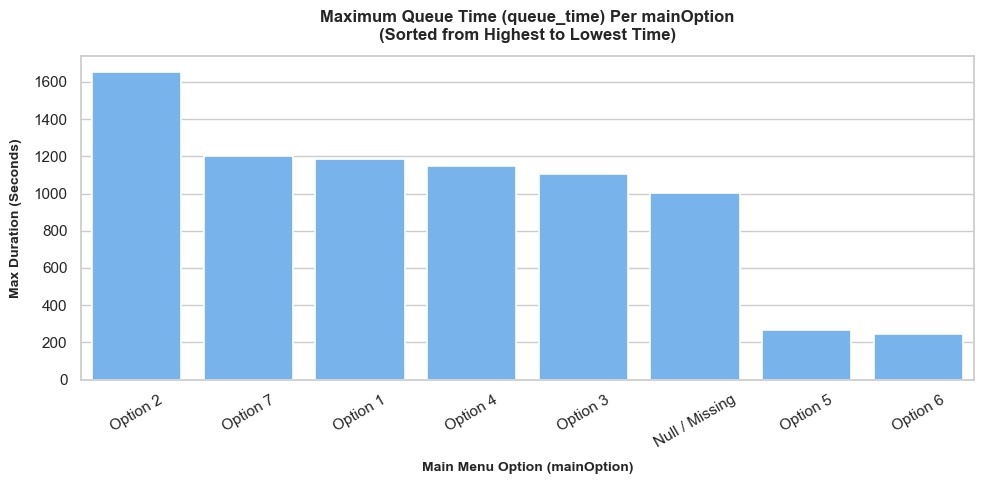

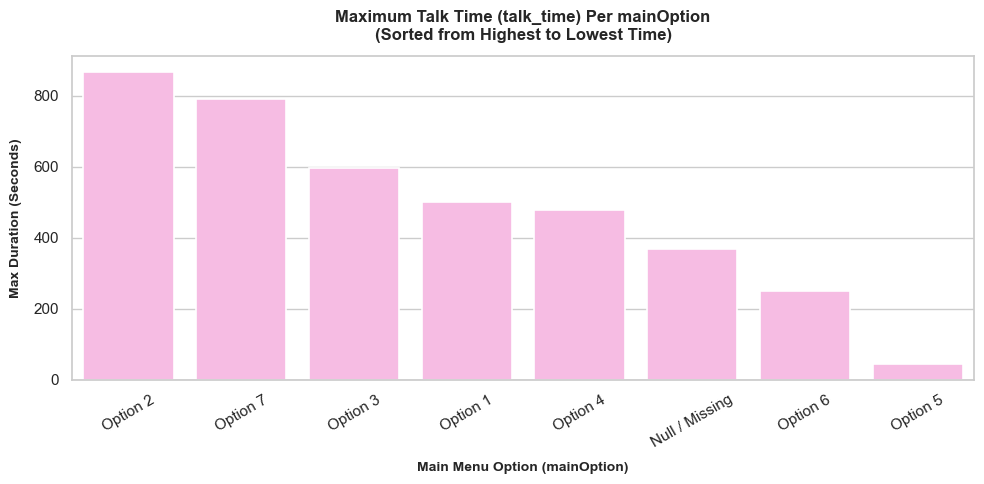

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean duration columns to ensure they are integers
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Calculate the maximum queue time and talk time for each group
highest_times_df = df.groupby('mainOption', dropna=False)[['queue_time', 'talk_time']].max().reset_index()

# Create clean text labels for the options
highest_times_df['Option_Label'] = highest_times_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# 3. Prepare data sorted from highest to lowest for each metric separately
queue_sorted_df = highest_times_df.sort_values(by='queue_time', ascending=False)
talk_sorted_df = highest_times_df.sort_values(by='talk_time', ascending=False)

# 4. Generate the Plots
sns.set_theme(style="whitegrid")

# --- CHART 1: MAXIMUM QUEUE TIME (Sorted Highest to Lowest) ---
fig1, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=queue_sorted_df, 
    x='Option_Label', 
    y='queue_time', 
    color='#66b3ff', # Cool Blue palette tone
    ax=ax1,
    edgecolor='white',
    linewidth=1.2
)
ax1.set_title("Maximum Queue Time (queue_time) Per mainOption\n(Sorted from Highest to Lowest Time)", fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel("Main Menu Option (mainOption)", fontsize=10, fontweight='bold', labelpad=8)
ax1.set_ylabel("Max Duration (Seconds)", fontsize=10, fontweight='bold', labelpad=8)
ax1.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('max_queue_time_sorted.png', dpi=300)
plt.show()

# --- CHART 2: MAXIMUM TALK TIME (Sorted Highest to Lowest) ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=talk_sorted_df, 
    x='Option_Label', 
    y='talk_time', 
    color='#ffb3e6', # Warm Pink palette tone
    ax=ax2,
    edgecolor='white',
    linewidth=1.2
)
ax2.set_title("Maximum Talk Time (talk_time) Per mainOption\n(Sorted from Highest to Lowest Time)", fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel("Main Menu Option (mainOption)", fontsize=10, fontweight='bold', labelpad=8)
ax2.set_ylabel("Max Duration (Seconds)", fontsize=10, fontweight='bold', labelpad=8)
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('max_talk_time_sorted.png', dpi=300)
plt.show()

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 1. Clean duration inputs to ensure absolute integer validation
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Build sorted dropdown select list options including Null structures
unique_options = df['mainOption'].dropna().unique()
sorted_numeric_options = sorted([float(opt) for opt in unique_options])

dropdown_options = [str(opt) for opt in sorted_numeric_options]
dropdown_options.append('Null / Missing')

# Helper function to convert raw seconds to a readable format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 3. Define the interactive plotting function
def view_top_20_calls(selected_main_option):
    # Filter the dataset based on the selected mainOption
    if selected_main_option == 'Null / Missing':
        filtered_df = df[df['mainOption'].isnull()].copy()
    else:
        filtered_df = df[df['mainOption'] == float(selected_main_option)].copy()
        
    total_available = len(filtered_df)
    
    print(f"================================================================")
    print(f"TOP 20 LONGEST INDIVIDUAL CALLS FOR: mainOption {selected_main_option}")
    print(f"================================================================")
    print(f"Total available calls in this group: {total_available}\n")
    
    if total_available == 0:
        print("⚠️ No call records found for this selection tier.")
        return

    # Extract the top 20 longest queue times
    # Using .index to create a unique label for each individual phone call row
    top_queue = filtered_df.sort_values(by='queue_time', ascending=False).head(20).copy()
    top_queue['Call_Label'] = top_queue.index.map(lambda x: f"Call #{x}")

    # Extract the top 20 longest talk times
    top_talk = filtered_df.sort_values(by='talk_time', ascending=False).head(20).copy()
    top_talk['Call_Label'] = top_talk.index.map(lambda x: f"Call #{x}")

    # 4. Generate the side-by-side horizontal bar plots
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Left Plot: Top 20 Queue Times (Cool Blue Palette)
    sns.barplot(
        data=top_queue,
        x='queue_time',
        y='Call_Label',
        color='#66b3ff',
        ax=axes[0],
        edgecolor='white',
        linewidth=1
    )
    axes[0].set_title(f"Top 20 Longest Queue Times\n(Max: {format_to_minutes(top_queue['queue_time'].max())})", fontsize=12, fontweight='bold', pad=12)
    axes[0].set_xlabel("Queue Time (Seconds)", fontsize=11)
    axes[0].set_ylabel("Unique Call Record ID", fontsize=11)

    # Right Plot: Top 20 Talk Times (Warm Pink Palette)
    sns.barplot(
        data=top_talk,
        x='talk_time',
        y='Call_Label',
        color='#ffb3e6',
        ax=axes[1],
        edgecolor='white',
        linewidth=1
    )
    axes[1].set_title(f"Top 20 Longest Talk Times\n(Max: {format_to_minutes(top_talk['talk_time'].max())})", fontsize=12, fontweight='bold', pad=12)
    axes[1].set_xlabel("Talk Time (Seconds)", fontsize=11)
    axes[1].set_ylabel("") # Hide y-label on the second chart to keep it clean

    plt.tight_layout()
    plt.show()

# 5. Generate Interactive UI Dropdown widget loop
interact(
    view_top_20_calls,
    selected_main_option=widgets.Dropdown(
        options=dropdown_options,
        value=dropdown_options[0],
        description='mainOption:',
        disabled=False,
    )
)

interactive(children=(Dropdown(description='mainOption:', options=('1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '…

<function __main__.view_top_20_calls(selected_main_option)>

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import numpy as np

# 1. Clean duration inputs to ensure absolute integer validation
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Build sorted dropdown select list options including Null structures
unique_options = df['mainOption'].dropna().unique()
sorted_numeric_options = sorted([float(opt) for opt in unique_options])

dropdown_options = [str(opt) for opt in sorted_numeric_options]
dropdown_options.append('Null / Missing')

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# Helper function to categorize and bin durations with strict LaTeX math formatting
def compute_interval_slices(time_series):
    count_0 = len(time_series[time_series == 0])
    count_300 = len(time_series[(time_series > 0) & (time_series <= 300)])
    count_600 = len(time_series[(time_series > 300) & (time_series <= 600)])
    count_above = len(time_series[time_series > 600])
    
    raw_counts = [count_0, count_300, count_600, count_above]
    raw_labels = [
        '0s (0m)', 
        '$> 0$s and $\\leq 300$s ($\\leq 5$m)', 
        '$> 300$s and $\\leq 600$s ($> 5$m to $\\leq 10$m)', 
        '$> 600$s ($> 10$m)'
    ]
    
    # Exclude empty categories with zero counts to keep the pie charts clean
    clean_pairs = [(count, lbl) for count, lbl in zip(raw_counts, raw_labels) if count > 0]
    
    if not clean_pairs:
        return [], []
    
    counts, labels = zip(*clean_pairs)
    return list(counts), list(labels)

# Helper function to cleanly position external callout labels with pointing arrows
def draw_callout_labels(ax, wedges, counts):
    total = sum(counts)
    if total == 0:
        return
    pct_labels = [f"{(c / total) * 100:.1f}%" for c in counts]
    
    ann_data = []
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        
        tx = 1.35 * x
        ty = 1.35 * y
        ann_data.append([i, x, y, tx, ty, ang])
        
    ann_data.sort(key=lambda item: item[5])
    
    # Multi-pass relaxation loop to prevent adjacent small labels from colliding
    for _ in range(5):
        for i in range(1, len(ann_data)):
            is_same_side = (ann_data[i-1][3] >= 0 and ann_data[i][3] >= 0) or (ann_data[i-1][3] < 0 and ann_data[i][3] < 0)
            if is_same_side:
                if abs(ann_data[i][4] - ann_data[i-1][4]) < 0.22:
                    overlap_shift = 0.22 - abs(ann_data[i][4] - ann_data[i-1][4])
                    if ann_data[i][4] >= ann_data[i-1][4]:
                        ann_data[i][4] += overlap_shift / 2.0
                        ann_data[i-1][4] -= overlap_shift / 2.0
                    else:
                        ann_data[i][4] -= overlap_shift / 2.0
                        ann_data[i-1][4] += overlap_shift / 2.0
                        
    for idx, x, y, tx, ty, ang in ann_data:
        horizontal_align = "left" if tx >= 0 else "right"
        ax.annotate(
            pct_labels[idx], 
            xy=(x, y), 
            xytext=(tx, ty),
            horizontalalignment=horizontal_align,
            verticalalignment='center',
            weight='bold',
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-|>", 
                color="gray", 
                lw=1.1,
                connectionstyle="arc3,rad=0"
            )
        )

# 3. Define the main interactive layout container function
def analyze_time_metrics(selected_main_option):
    if selected_main_option == 'Null / Missing':
        main_df = df[df['mainOption'].isnull()]
    else:
        main_df = df[df['mainOption'] == float(selected_main_option)]
        
    total_calls = len(main_df)
    
    print(f"================================================================")
    print(f" DYNAMIC SUB-OPTION GRID PROFILE FOR: mainOption {selected_main_option}")
    print(f"================================================================")
    print(f"Total Calls in Selected Main Option: {total_calls}\n")
    
    if total_calls == 0:
        print("⚠️ No operational call records found for this selection tier.")
        return
        
    # Isolate all sub-options active under this main option block
    raw_sub_options = main_df['subOption'].unique()
    # Sort sub-options nicely, placing Null values at the very bottom of the grid
    sub_options = sorted([str(x) for x in raw_sub_options if pd.notnull(x)])
    if any(pd.isnull(x) for x in raw_sub_options):
        sub_options.append('Null / Missing')
        
    num_subs = len(sub_options)
    
    # Generate the dynamic subplots figure grid layout base
    fig, axes = plt.subplots(num_subs, 2, figsize=(15, 6.5 * num_subs), squeeze=False)
    
    # Two distinct color palettes
    queue_palette = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']  # Cool Tones (Blues/Greens)
    talk_palette = ['#b19cd9', '#ffb3e6', '#f4a460', '#e6c280']   # Warm Tones (Purples/Pinks)
    
    # Loop over each sub-option to build metrics and rows dynamically
    for row_idx, sub_opt in enumerate(sub_options):
        if sub_opt == 'Null / Missing':
            sub_df = main_df[main_df['subOption'].isnull()]
            sub_title_label = "subOption: Null / Missing"
        else:
            sub_df = main_df[main_df['subOption'] == sub_opt]
            sub_title_label = f"subOption: '{sub_opt}'"
            
        sub_total = len(sub_df)
        
        print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print(f"{sub_title_label} — Layer Performance Breakdown ({sub_total} Calls)")
        print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        
        if sub_total == 0:
            print(" No data available for this specific subset tier.\n")
            axes[row_idx, 0].axis('off')
            axes[row_idx, 1].axis('off')
            continue
            
        # Fetch extreme endpoints for the sub-option subset
        max_q = sub_df['queue_time'].max()
        min_q = sub_df['queue_time'].min()
        max_t = sub_df['talk_time'].max()
        min_t = sub_df['talk_time'].min()
        
        print(f"  • Queue Time (queue_time) Extremes: Max = {format_to_minutes(max_q)} | Min = {format_to_minutes(min_q)}")
        print(f"  • Talk Time (talk_time) Extremes:   Max = {format_to_minutes(max_t)} | Min = {format_to_minutes(min_t)}\n")
        
        # Split interval counts
        q_counts, q_labels = compute_interval_slices(sub_df['queue_time'])
        t_counts, t_labels = compute_interval_slices(sub_df['talk_time'])
        
        # --- CHART 1: QUEUE TIME PIE WHEEL ---
        ax_q = axes[row_idx, 0]
        if q_counts:
            total_q = sum(q_counts)
            q_legend_labels = [f"{lbl} — {(c / total_q) * 100:.1f}%" for c, lbl in zip(q_counts, q_labels)]
            wedges_q, texts_q = ax_q.pie(
                q_counts, labels=None, startangle=90,
                colors=queue_palette[:len(q_counts)],
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
            )
            draw_callout_labels(ax_q, wedges_q, q_counts)
            ax_q.legend(wedges_q, q_legend_labels, title="Queue Intervals", loc="upper center", 
                        bbox_to_anchor=(0.5, -0.16), fontsize=8.5, title_fontsize=9.5, frameon=True)
            ax_q.set_title(f"{sub_title_label}\nQueue Time (queue_time)", fontsize=11, fontweight='bold', pad=12)
            ax_q.set_xlim(-1.7, 1.7)
            ax_q.set_ylim(-1.7, 1.7)
        else:
            ax_q.text(0.5, 0.5, 'No Queue Metrics Logged', ha='center', va='center', color='gray')
            ax_q.axis('off')
            
        # --- CHART 2: TALK TIME PIE WHEEL ---
        ax_t = axes[row_idx, 1]
        if t_counts:
            total_t = sum(t_counts)
            t_legend_labels = [f"{lbl} — {(c / total_t) * 100:.1f}%" for c, lbl in zip(t_counts, t_labels)]
            wedges_t, texts_t = ax_t.pie(
                t_counts, labels=None, startangle=90,
                colors=talk_palette[:len(t_counts)],
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
            )
            draw_callout_labels(ax_t, wedges_t, t_counts)
            ax_t.legend(wedges_t, t_legend_labels, title="Talk Intervals", loc="upper center", 
                        bbox_to_anchor=(0.5, -0.16), fontsize=8.5, title_fontsize=9.5, frameon=True)
            ax_t.set_title(f"{sub_title_label}\nTalk Time (talk_time)", fontsize=11, fontweight='bold', pad=12)
            ax_t.set_xlim(-1.7, 1.7)
            ax_t.set_ylim(-1.7, 1.7)
        else:
            ax_t.text(0.5, 0.5, 'No Talk Metrics Logged', ha='center', va='center', color='gray')
            ax_t.axis('off')
            
    # hspace=0.75 leaves plenty of clear breathing room so row legends do not touch titles underneath
    plt.subplots_adjust(hspace=0.75, wspace=0.35)
    plt.show()

# 4. Generate Interactive UI Dropdown widget loop
interact(
    analyze_time_metrics,
    selected_main_option=widgets.Dropdown(
        options=dropdown_options,
        value=dropdown_options[0],
        description='mainOption:',
        disabled=False,
    )
)

interactive(children=(Dropdown(description='mainOption:', options=('1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '…

<function __main__.analyze_time_metrics(selected_main_option)>

# Service Status/ Verification of the account

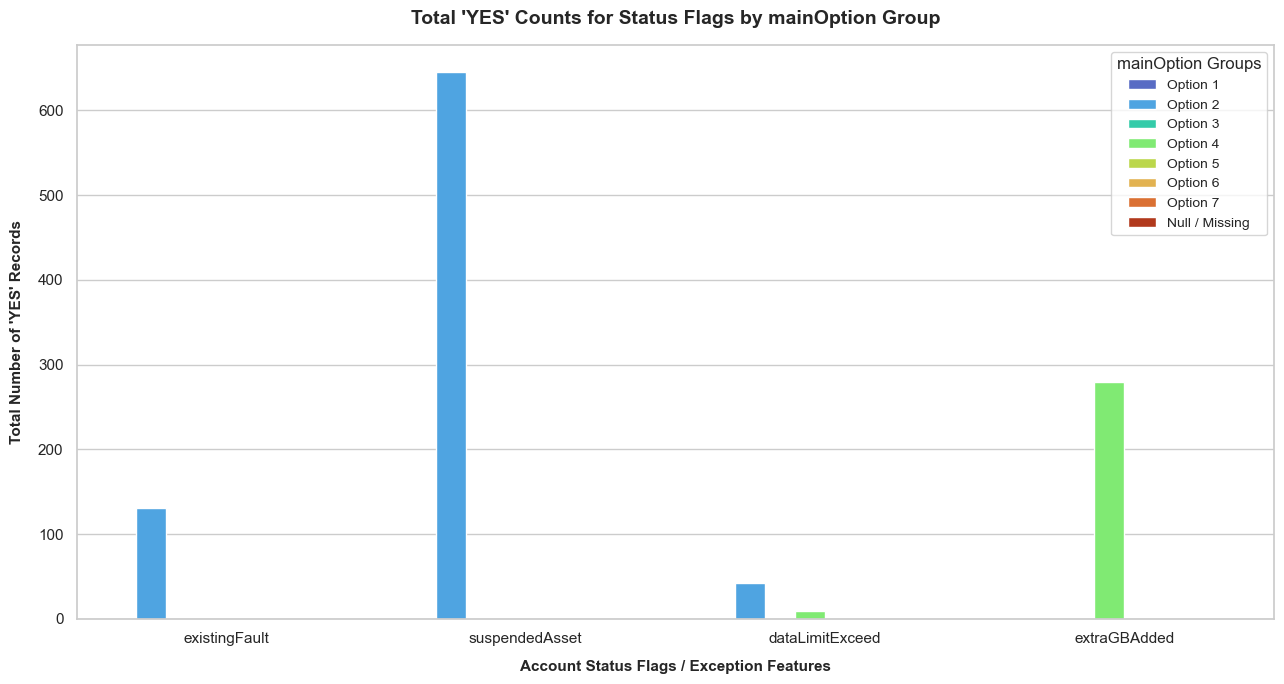

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. First, combine mainOption 14.0 and 11.0 into 7.0 as requested previously
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Create a clean copy of the dataframe for plotting
plot_df = df.copy()

# Format the mainOption labels cleanly, including the Null / Missing group
plot_df['mainOption_Label'] = plot_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# 3. Define the 4 status features we want to analyze
features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# Convert the 'YES'/'NO' text values into numeric 1s and 0s for easy summing
for col in features:
    plot_df[col + '_numeric'] = (plot_df[col] == 'YES').astype(int)

# 4. Melt the dataframe into a long format suitable for Seaborn grouped bar charts
numeric_feature_cols = [col + '_numeric' for col in features]
melted_df = plot_df.melt(
    id_vars=['mainOption_Label'], 
    value_vars=numeric_feature_cols, 
    var_name='Status_Feature', 
    value_name='Is_YES'
)

# Clean up the feature names so they display beautifully on the X-axis
melted_df['Status_Feature'] = melted_df['Status_Feature'].str.replace('_numeric', '')

# Sort the mainOption labels so the legend appears in perfect numerical order
hue_order = sorted([lbl for lbl in melted_df['mainOption_Label'].unique() if lbl != 'Null / Missing'])
if 'Null / Missing' in melted_df['mainOption_Label'].unique():
    hue_order.append('Null / Missing')

# 5. Generate the Seaborn Visual Layout
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 7))

# Draw the grouped bar chart using the 'sum' estimator to count the 'YES' values
sns.barplot(
    data=melted_df,
    x='Status_Feature',
    y='Is_YES',
    hue='mainOption_Label',
    hue_order=hue_order,
    estimator=sum,
    errorbar=None,
    palette='turbo',
    ax=ax,
    edgecolor='white',
    linewidth=1
)

# Customize titles and axis formatting for high readability
ax.set_title("Total 'YES' Counts for Status Flags by mainOption Group", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Account Status Flags / Exception Features", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Total Number of 'YES' Records", fontsize=11, fontweight='bold', labelpad=10)

# Position the legend cleanly
ax.legend(title="mainOption Groups", loc="upper right", frameon=True, fontsize=10)

# Set tight layout to ensure no elements are clipped or truncated
plt.tight_layout()

# Save and display the visualization
plt.savefig('status_flags_by_mainoption.png', dpi=300)
plt.show()

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 1. Standardize mainOption by combining 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Preprocess status columns: fill missing values with 'NO'
features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]
df[features] = df[features].fillna("NO")

# 3. Create sorted dropdown list options including the Null group
unique_mains = df['mainOption'].dropna().unique()
sorted_mains = sorted([float(opt) for opt in unique_mains])

dropdown_options = [str(opt) for opt in sorted_mains]
dropdown_options.append('Null / Missing')

# 4. Define the interactive dashboard function
def analyze_suboption_status_flags(selected_main_option):
    # Filter the dataset based on the selected mainOption
    if selected_main_option == 'Null / Missing':
        filtered_df = df[df['mainOption'].isnull()].copy()
    else:
        filtered_df = df[df['mainOption'] == float(selected_main_option)].copy()
        
    total_calls = len(filtered_df)
    
    print(f"================================================================")
    print(f" 📊 SUB-OPTION STATUS DISTRIBUTION FOR: mainOption {selected_main_option}")
    print(f"================================================================")
    print(f"🔹 Total Calls in this group: {total_calls}\n")
    
    if total_calls == 0:
        print("⚠️ No call records found for this selection tier.")
        return

    # Clean and label subOption strings, including Nulls
    filtered_df['subOption_Label'] = filtered_df['subOption'].apply(
        lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
    )
    
    # Convert 'YES'/'NO' text data into numeric 1s and 0s for aggregation
    for col in features:
        filtered_df[col + '_numeric'] = (filtered_df[col] == 'YES').astype(int)
        
    # Melt the dataframe into a long format for Seaborn grouped plotting
    numeric_cols = [col + '_numeric' for col in features]
    melted_df = filtered_df.melt(
        id_vars=['subOption_Label'],
        value_vars=numeric_cols,
        var_name='Status_Feature',
        value_name='Is_YES'
    )
    
    # Clean up feature column names for the X-axis labels
    melted_df['Status_Feature'] = melted_df['Status_Feature'].str.replace('_numeric', '')
    
    # Check if any 'YES' records actually exist in this selection to prevent empty plotting
    if melted_df['Is_YES'].sum() == 0:
        print("ℹ️ Note: There are 0 'YES' counts across all status flags for this mainOption.")
        print("   (A chart will not be drawn because all bar heights are zero).")
        return

    # Establish a clean sorting order for the legend (hue_order)
    hue_order = sorted([lbl for lbl in melted_df['subOption_Label'].unique() if lbl != 'Null / Missing'])
    if 'Null / Missing' in melted_df['subOption_Label'].unique():
        hue_order.append('Null / Missing')

    # 5. Generate the Seaborn Grouped Bar Chart
    sns.set_theme(style="whitegrid")
    
    # Use subplots to safely manage layout dimensions without using .figure()
    fig, ax = plt.subplots(figsize=(12, 6.5))
    
    sns.barplot(
        data=melted_df,
        x='Status_Feature',
        y='Is_YES',
        hue='subOption_Label',
        hue_order=hue_order,
        estimator=sum, # Computes the total number of 'YES' instances
        errorbar=None,
        palette='turbo', # Distinct palette mapping for sub-options
        ax=ax,
        edgecolor='white',
        linewidth=1.2
    )
    
    # Chart styling and label polish
    ax.set_title(f"Total 'YES' Counts for Status Flags broken down by subOption\n(Filtered for mainOption {selected_main_option})", fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("Account Status Flags / Exception Features", fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel("Total Number of 'YES' Records", fontsize=11, fontweight='bold', labelpad=10)
    
    # Position the legend clearly
    ax.legend(title="Sub-Options (subOption)", loc="upper right", frameon=True, fontsize=10)
    
    plt.tight_layout()
    plt.show()

# 6. Generate the Interactive Dropdown Menu Controller UI Component
interact(
    analyze_suboption_status_flags,
    selected_main_option=widgets.Dropdown(
        options=dropdown_options,
        value=dropdown_options[0],
        description='mainOption:',
        disabled=False,
    )
)

interactive(children=(Dropdown(description='mainOption:', options=('1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '…

<function __main__.analyze_suboption_status_flags(selected_main_option)>

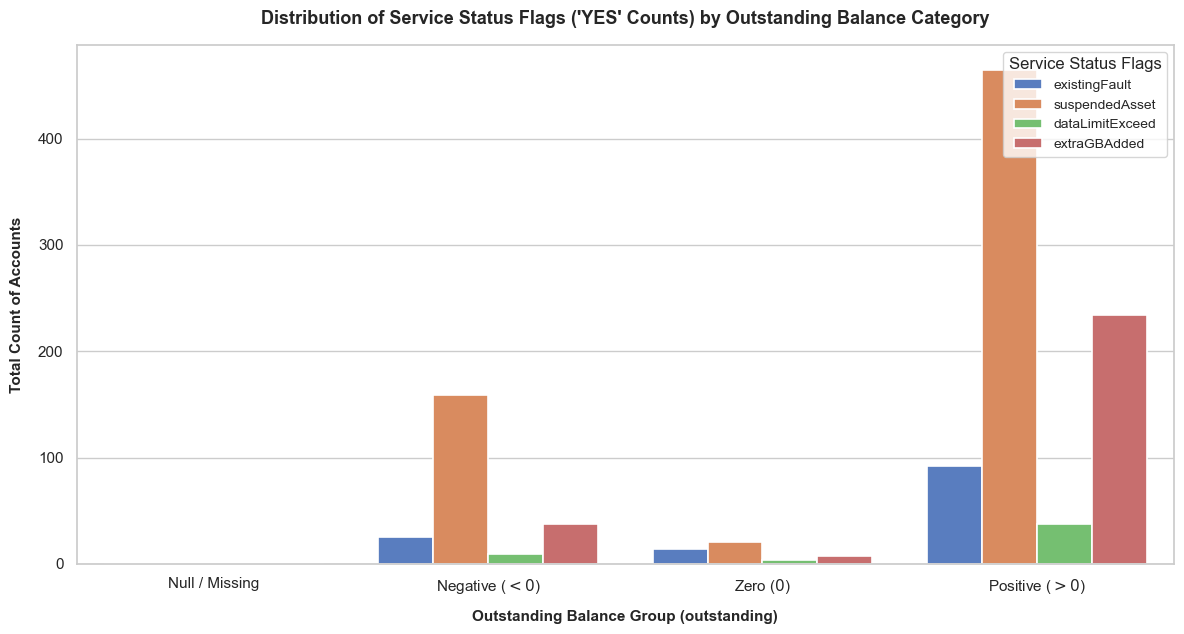

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure service status columns are filled and clean
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]
df[status_features] = df[status_features].fillna("NO")

# 2. Define a helper function to bucket the outstanding column cleanly
def categorize_outstanding(val):
    if pd.isnull(val):
        return 'Null / Missing'
    elif val < 0:
        return 'Negative ($< 0$)'
    elif val == 0:
        return 'Zero ($0$)'
    else:
        return 'Positive ($> 0$)'

# Apply the bucketing function
df['outstanding_bucket'] = df['outstanding'].apply(categorize_outstanding)

# 3. Convert 'YES'/'NO' text to numeric 1s and 0s for quick aggregation
plot_df = df.copy()
for col in status_features:
    plot_df[col + '_numeric'] = (plot_df[col] == 'YES').astype(int)

# 4. Group by the outstanding buckets and sum up the 'YES' counts
numeric_cols = [col + '_numeric' for col in status_features]
grouped_df = plot_df.groupby('outstanding_bucket')[numeric_cols].sum().reset_index()

# Rename columns back to their original names for clean labels in the legend
grouped_df.columns = ['outstanding_bucket'] + status_features

# 5. Melt the dataframe into a long format for Seaborn grouped plotting
melted_df = grouped_df.melt(
    id_vars=['outstanding_bucket'], 
    value_vars=status_features,
    var_name='Service_Status', 
    value_name='Account_Count'
)

# Define a strict logical sequence for the categories on the X-axis
x_order = ['Null / Missing', 'Negative ($< 0$)', 'Zero ($0$)', 'Positive ($> 0$)']

# 6. Generate the Seaborn Grouped Bar Chart
sns.set_theme(style="whitegrid")

# Create figure and axis layout canvas safely (avoiding .figure() as per styling)
fig, ax = plt.subplots(figsize=(12, 6.5))

sns.barplot(
    data=melted_df,
    x='outstanding_bucket',
    y='Account_Count',
    hue='Service_Status',
    order=x_order,
    palette='muted',
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# Custom title and axis labels
ax.set_title("Distribution of Service Status Flags ('YES' Counts) by Outstanding Balance Category", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Outstanding Balance Group (outstanding)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Total Count of Accounts", fontsize=11, fontweight='bold', labelpad=10)

# Position and style the legend clearly
ax.legend(title="Service Status Flags", loc="upper right", frameon=True, fontsize=10)

# Apply spacing optimization to ensure no text overlaps or gets clipped
plt.tight_layout()

# Save and display the visualization
plt.savefig('service_status_by_outstanding.png', dpi=300)
plt.show()

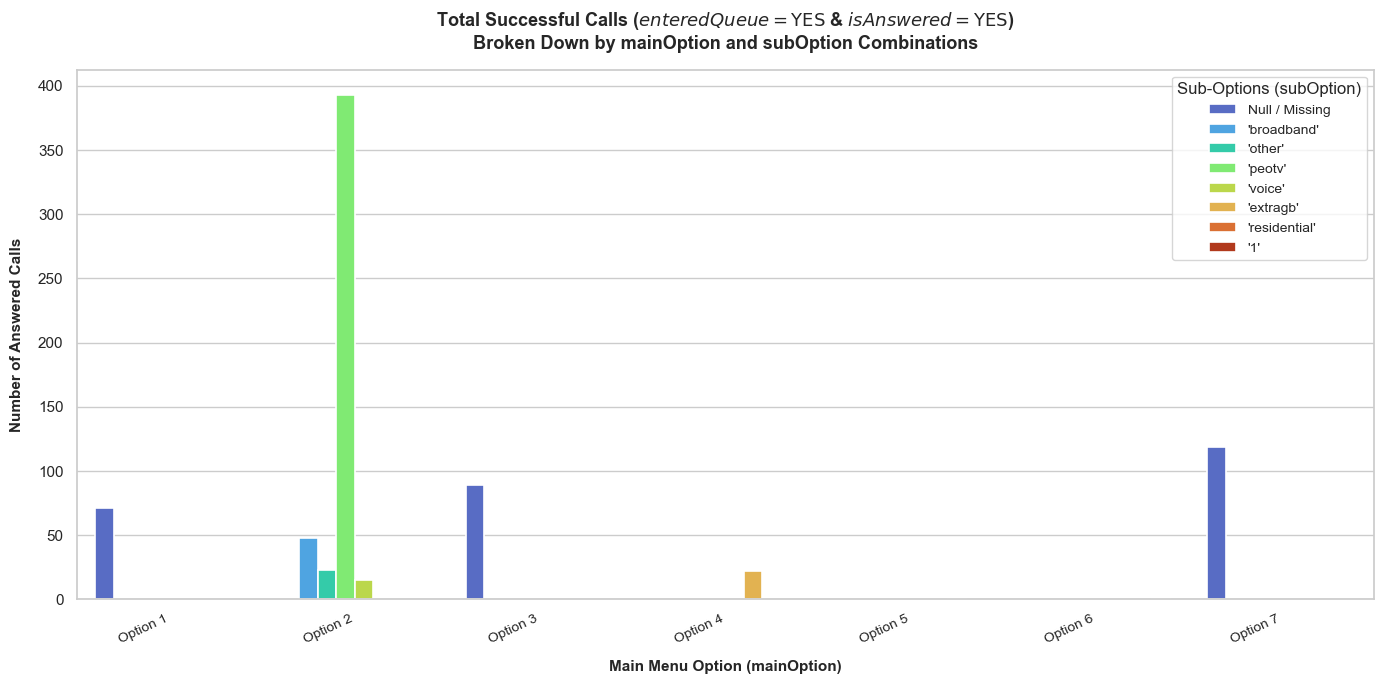

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Keep the requested previous adjustment (combining 14.0 and 11.0 into 7.0)
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Filter rows where the call successfully entered the queue AND was answered by an agent
condition = (df['enteredQueue'] == 'YES') & (df['isAnswered'] == 'YES')
success_df = df[condition].copy()

# 3. Process missing inputs so 'Null / Missing' groupings remain completely visible
success_df['mainOption_Label'] = success_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)
success_df['subOption_Label'] = success_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# 4. Compute call counts for each combination pair
summary_df = success_df.groupby(['mainOption_Label', 'subOption_Label']).size().reset_index(name='Successful_Calls')

# Create a clean sorting structure for the X-axis (numeric options first, Null group last)
x_order = sorted([lbl for lbl in summary_df['mainOption_Label'].unique() if lbl != 'Null / Missing'])
if 'Null / Missing' in summary_df['mainOption_Label'].unique():
    x_order.append('Null / Missing')

# 5. Generate the Seaborn Grouped Bar Chart Workspace
sns.set_theme(style="whitegrid")

# Create a clear figure and axis layout grid (Avoiding .figure() per standard instructions)
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=summary_df,
    x='mainOption_Label',
    y='Successful_Calls',
    hue='subOption_Label',
    order=x_order,
    palette='turbo', # High contrast color spectrum mapping
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Formatting Titles and Labels using standard LaTeX math notations
ax.set_title("Total Successful Calls ($enteredQueue = \\text{YES}$ & $isAnswered = \\text{YES}$)\nBroken Down by mainOption and subOption Combinations", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Answered Calls", fontsize=11, fontweight='bold', labelpad=10)

# Polish the chart legend position
ax.legend(title="Sub-Options (subOption)", loc="upper right", frameon=True, fontsize=10)

# Rotate labels slightly to ensure they remain non-overlapping and highly readable
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()

# Save and render the plot visualization
plt.savefig('successful_queue_calls_matrix.png', dpi=300)
plt.show()

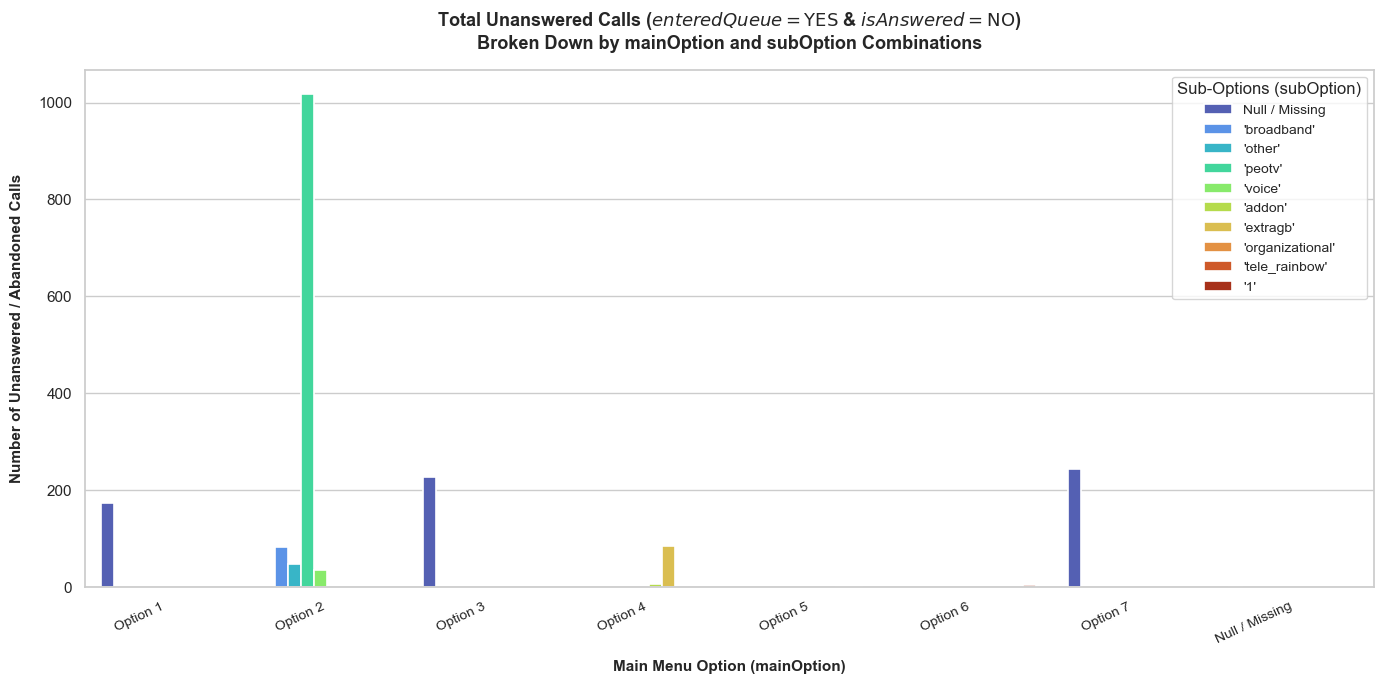

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Keep the requested adjustment (combining 14.0 and 11.0 into 7.0)
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Filter rows where the call entered the queue BUT was NOT answered by an agent
condition = (df['enteredQueue'] == 'YES') & (df['isAnswered'] == 'NO')
unanswered_df = df[condition].copy()

# 3. Process missing inputs so 'Null / Missing' groupings remain completely visible
unanswered_df['mainOption_Label'] = unanswered_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)
unanswered_df['subOption_Label'] = unanswered_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# 4. Compute call counts for each combination pair
summary_df = unanswered_df.groupby(['mainOption_Label', 'subOption_Label']).size().reset_index(name='Unanswered_Calls')

# Create a clean sorting structure for the X-axis (numeric options first, Null group last)
x_order = sorted([lbl for lbl in summary_df['mainOption_Label'].unique() if lbl != 'Null / Missing'])
if 'Null / Missing' in summary_df['mainOption_Label'].unique():
    x_order.append('Null / Missing')

# 5. Generate the Seaborn Grouped Bar Chart Workspace
sns.set_theme(style="whitegrid")

# Create a clear figure and axis layout grid
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=summary_df,
    x='mainOption_Label',
    y='Unanswered_Calls',
    hue='subOption_Label',
    order=x_order,
    palette='turbo', # High contrast color spectrum mapping
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Formatting Titles and Labels using standard LaTeX math notations
ax.set_title("Total Unanswered Calls ($enteredQueue = \\text{YES}$ & $isAnswered = \\text{NO}$)\nBroken Down by mainOption and subOption Combinations", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Unanswered / Abandoned Calls", fontsize=11, fontweight='bold', labelpad=10)

# Polish the chart legend position
ax.legend(title="Sub-Options (subOption)", loc="upper right", frameon=True, fontsize=10)

# Rotate labels slightly to ensure they remain non-overlapping and highly readable
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()

# Save and render the plot visualization
plt.savefig('unanswered_queue_calls_matrix.png', dpi=300)
plt.show()

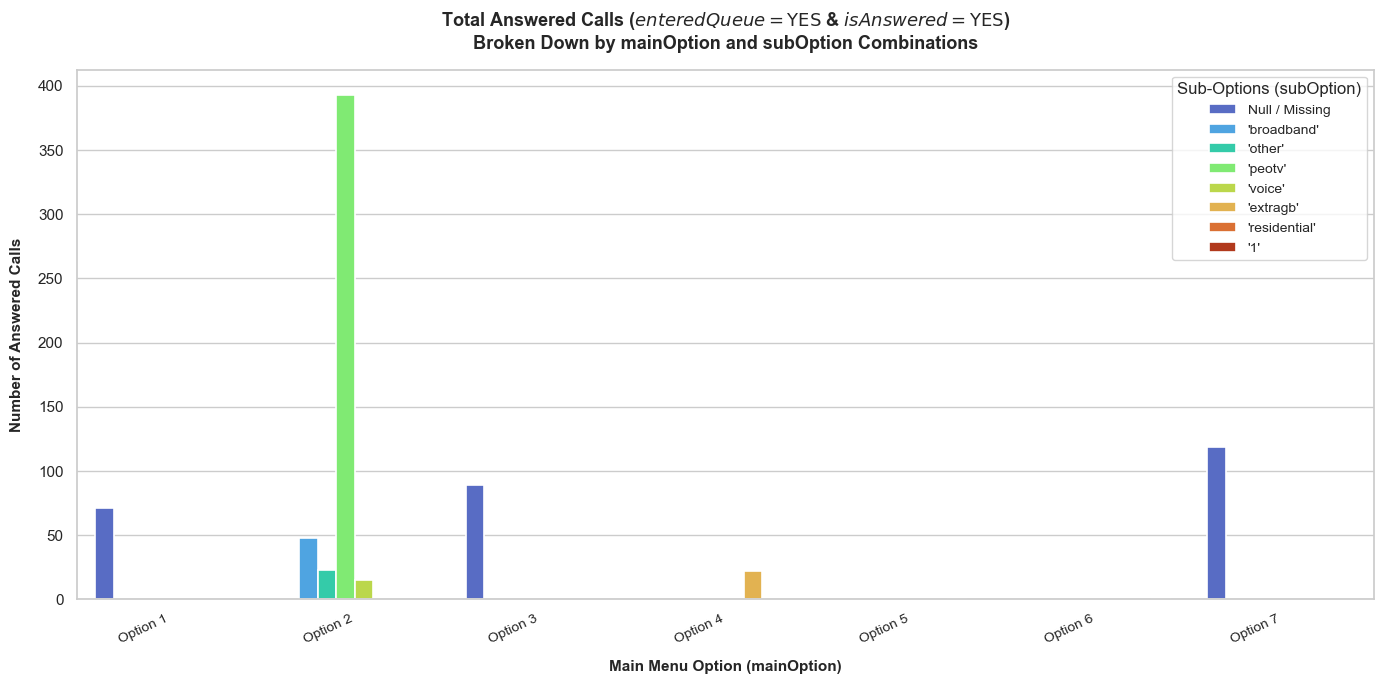

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Keep the requested adjustment (combining 14.0 and 11.0 into 7.0)
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Filter rows where the call entered the queue and was answered by an agent
condition = (df['enteredQueue'] == 'YES') & (df['isAnswered'] == 'YES')
answered_df = df[condition].copy()

# 3. Process missing inputs so 'Null / Missing' groupings remain completely visible
answered_df['mainOption_Label'] = answered_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)
answered_df['subOption_Label'] = answered_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# 4. Compute call counts for each combination pair
summary_df = answered_df.groupby(['mainOption_Label', 'subOption_Label']).size().reset_index(name='Answered_Calls')

# Create a clean sorting structure for the X-axis (numeric options first, Null group last)
x_order = sorted([lbl for lbl in summary_df['mainOption_Label'].unique() if lbl != 'Null / Missing'])
if 'Null / Missing' in summary_df['mainOption_Label'].unique():
    x_order.append('Null / Missing')

# 5. Generate the Seaborn Grouped Bar Chart Workspace
sns.set_theme(style="whitegrid")

# Create a clear figure and axis layout grid
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=summary_df,
    x='mainOption_Label',
    y='Answered_Calls',
    hue='subOption_Label',
    order=x_order,
    palette='turbo', # High contrast color spectrum mapping
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Formatting Titles and Labels using standard LaTeX math notations
ax.set_title("Total Answered Calls ($enteredQueue = \\text{YES}$ & $isAnswered = \\text{YES}$)\nBroken Down by mainOption and subOption Combinations", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Answered Calls", fontsize=11, fontweight='bold', labelpad=10)

# Polish the chart legend position
ax.legend(title="Sub-Options (subOption)", loc="upper right", frameon=True, fontsize=10)

# Rotate labels slightly to ensure they remain non-overlapping and highly readable
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()

# Save and render the plot visualization
plt.show()

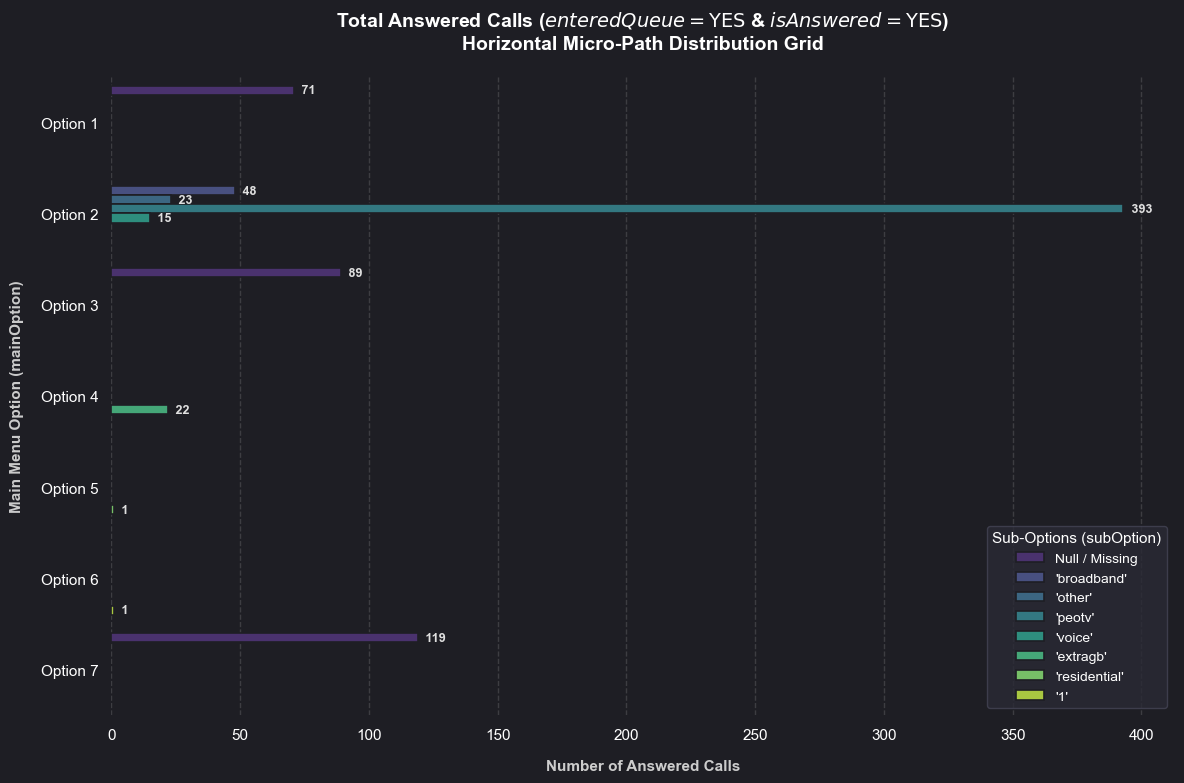

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Maintain consistency by combining mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Filter rows for successful answered calls
condition = (df['enteredQueue'] == 'YES') & (df['isAnswered'] == 'YES')
success_df = df[condition].copy()

# 3. Clean string text labels for the options
success_df['mainOption_Label'] = success_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)
success_df['subOption_Label'] = success_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# 4. Compute call volumes for each combination pair
summary_df = success_df.groupby(['mainOption_Label', 'subOption_Label']).size().reset_index(name='Answered_Calls')

# Create a clean sorting structure for the Y-axis (numeric options first, Null group last)
y_order = sorted([lbl for lbl in summary_df['mainOption_Label'].unique() if lbl != 'Null / Missing'])
if 'Null / Missing' in summary_df['mainOption_Label'].unique():
    y_order.append('Null / Missing')

# 5. Apply the Dark/Custom Theme properties matching your reference chart
plt.style.use('dark_background')  # Switches the canvas layout grid to a sleek dark aesthetic
fig, ax = plt.subplots(figsize=(12, 8))

# Set custom facecolors for absolute color cohesion
fig.patch.set_facecolor('#1e1e24')
ax.set_facecolor('#1e1e24')

# 6. Generate the Horizontal Grouped Bar Chart
sns.barplot(
    data=summary_df,
    x='Answered_Calls',       # Numeric scale on X-axis for horizontal progression
    y='mainOption_Label',     # Primary groups on Y-axis
    hue='subOption_Label',    # Side-by-side sub-categories
    order=y_order,
    palette='viridis',        # A vibrant, modern palette that pops on dark backgrounds
    ax=ax,
    edgecolor='#1e1e24',
    linewidth=1.2
)

# 7. Add exact count digits dynamically next to the tip of each horizontal bar
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Only label bars that contain counts
        ax.annotate(
            f" {int(width)}", 
            (width, p.get_y() + p.get_height() / 2.), 
            va='center', 
            ha='left',
            fontsize=9, 
            weight='bold',
            color='#e0e0e0',
            xytext=(3, 0), 
            textcoords='offset points'
        )

# 8. Customize Titles, Labels, and Clean Gridlines
ax.set_title("Total Answered Calls ($enteredQueue = \\text{YES}$ & $isAnswered = \\text{YES}$)\nHorizontal Micro-Path Distribution Grid", 
             fontsize=14, fontweight='bold', pad=20, color='#ffffff')
ax.set_xlabel("Number of Answered Calls", fontsize=11, fontweight='bold', labelpad=12, color='#cccccc')
ax.set_ylabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=12, color='#cccccc')

# Style the legend to fit seamlessly into the dark workspace
ax.legend(title="Sub-Options (subOption)", loc="lower right", frameon=True, 
          facecolor='#2a2a35', edgecolor='#444455', fontsize=10, title_fontsize=11)

# Configure soft vertical grid lines matching the reference style
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='#888888')
ax.yaxis.grid(False) # Keep the primary rows clean

# Remove chart borders for a flatter, modern appearance
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save the high-resolution visualization asset locally
plt.savefig('horizontal_answered_calls_matrix.png', dpi=300, facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

# Reset layout defaults back to standard light theme for subsequent notebook cells
plt.style.use('default')

In [44]:
import pandas as pd

# 1. Maintain consistency by combining mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Filter rows for successful connections (Entered Queue AND Answered)
condition = (df['enteredQueue'] == 'YES') & (df['isAnswered'] == 'YES')
success_df = df[condition].copy()

# 3. Process missing entries so 'Null / Missing' values don't get hidden
success_df['mainOption_Label'] = success_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)
success_df['subOption_Label'] = success_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# 4. Compute call volumes for each unique combination pair
breakdown_df = (
    success_df.groupby(['mainOption_Label', 'subOption_Label'], dropna=False)
    .size()
    .reset_index(name='Total_Answered_Calls')
)

# 5. Sort combinations from highest volume to lowest
breakdown_df = breakdown_df.sort_values(by='Total_Answered_Calls', ascending=False).reset_index(drop=True)

# 6. Print out the formatted text leaderboard report
print("========================================================================")
print(" 📞 ANSWERED CALLS BREAKDOWN BY MENU COMBINATIONS (HIGHEST TO LOWEST)")
print("    Criteria: enteredQueue == 'YES' & isAnswered == 'YES'")
print("========================================================================")
print(f"{'Main Menu Option':<22} | {'Sub-Option Route':<25} | {'Total Answered Calls'}")
print("-" * 72)

for index, row in breakdown_df.iterrows():
    # Tag the single highest volume driver with a crown icon
    prefix = "👑 " if index == 0 else "   "
    print(f"{prefix}{row['mainOption_Label']:<19} | {row['subOption_Label']:<25} | {row['Total_Answered_Calls']:,} calls")

print("========================================================================")

 📞 ANSWERED CALLS BREAKDOWN BY MENU COMBINATIONS (HIGHEST TO LOWEST)
    Criteria: enteredQueue == 'YES' & isAnswered == 'YES'
Main Menu Option       | Sub-Option Route          | Total Answered Calls
------------------------------------------------------------------------
👑 Option 2            | 'peotv'                   | 393 calls
   Option 7            | Null / Missing            | 119 calls
   Option 3            | Null / Missing            | 89 calls
   Option 1            | Null / Missing            | 71 calls
   Option 2            | 'broadband'               | 48 calls
   Option 2            | 'other'                   | 23 calls
   Option 4            | 'extragb'                 | 22 calls
   Option 2            | 'voice'                   | 15 calls
   Option 5            | 'residential'             | 1 calls
   Option 6            | '1'                       | 1 calls


In [45]:
import pandas as pd

# 1. Maintain consistency by combining mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Calculate the call counts for each mainOption (including Null/Missing entries)
# value_counts() automatically sorts from highest to lowest by default
call_counts = df['mainOption'].value_counts(dropna=False).reset_index()
call_counts.columns = ['mainOption', 'call_count']

# 3. Format clean text labels for printing out the results
call_counts['Option_Label'] = call_counts['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"mainOption {int(x)}"
)

print("================================================================")
print(" 📊 TOTAL CALL VOLUME PER mainOption (RANKED HIGHEST TO LOWEST)")
print("================================================================")

# 4. Print out the ranked summary row by row
for index, row in call_counts.iterrows():
    # Mark the very first row as the highest rank winner
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {row['call_count']} calls")

print("================================================================")

 📊 TOTAL CALL VOLUME PER mainOption (RANKED HIGHEST TO LOWEST)
👑 HIGHEST ➔ mainOption 2: 1830 calls
🔹 Null / Missing: 1041 calls
🔹 mainOption 4: 577 calls
🔹 mainOption 3: 524 calls
🔹 mainOption 7: 365 calls
🔹 mainOption 1: 248 calls
🔹 mainOption 5: 13 calls
🔹 mainOption 6: 6 calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\1793798065.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


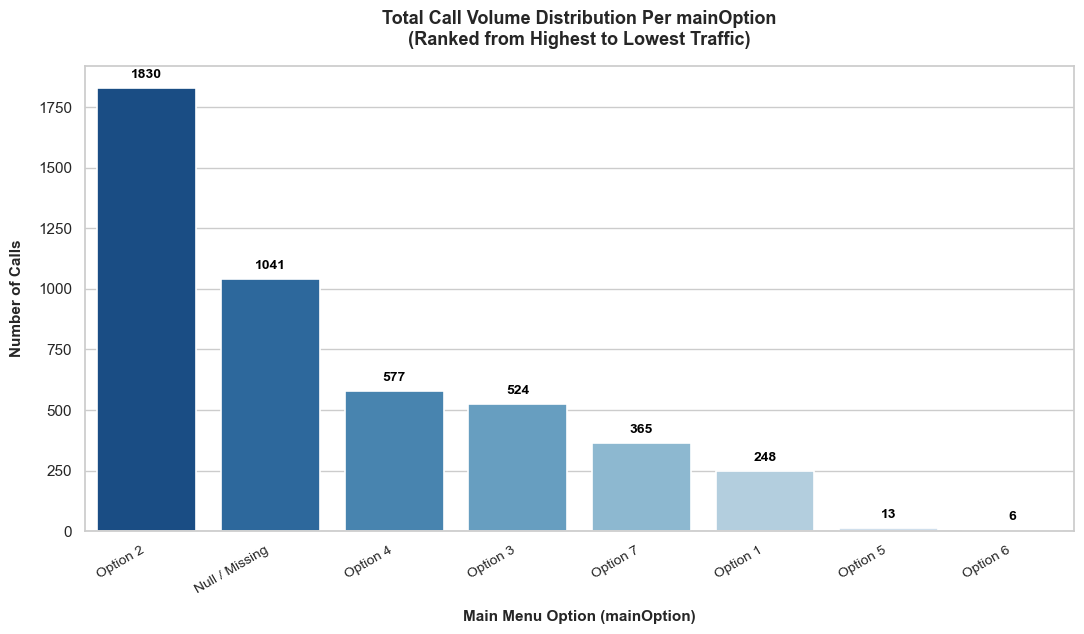

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Combine mainOption 14.0 and 11.0 into 7.0 for consistency
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Calculate call counts for each mainOption (including Null/Missing values)
main_counts = df['mainOption'].value_counts(dropna=False).reset_index()
main_counts.columns = ['mainOption', 'call_count']

# 3. Format clean text labels for the X-axis bars
main_counts['Option_Label'] = main_counts['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# 4. Sort the dataframe from the highest call count volume to the lowest
main_counts = main_counts.sort_values(by='call_count', ascending=False)

# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use the 'Blues_r' palette to automatically give a clean gradient from highest to lowest volume
sns.barplot(
    data=main_counts,
    x='Option_Label',
    y='call_count',
    palette='Blues_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Add the exact call count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}", 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold',
        color='black',
        xytext=(0, 5), 
        textcoords='offset points'
    )

# Customize title and axis text labels
ax.set_title("Total Call Volume Distribution Per mainOption\n(Ranked from Highest to Lowest Traffic)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Calls", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels to prevent text crowding or overlapping lines
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()

# Save the high-resolution figure directly to your directory path
plt.savefig('main_options_ranked_volume.png', dpi=300)

In [47]:
import pandas as pd

# 1. Calculate the call counts for each subOption (including Null/Missing entries)
# value_counts() automatically sorts from highest to lowest by default
sub_counts = df['subOption'].value_counts(dropna=False).reset_index()
sub_counts.columns = ['subOption', 'call_count']

# 2. Format clean text labels for printing out the results
sub_counts['Option_Label'] = sub_counts['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"subOption '{x}'"
)

print("================================================================")
print(" 📊 TOTAL CALL VOLUME PER subOption (RANKED HIGHEST TO LOWEST)")
print("================================================================")

# 3. Print out the ranked summary row by row
for index, row in sub_counts.iterrows():
    # Mark the very first row as the highest rank winner
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {row['call_count']} calls")

print("================================================================")

 📊 TOTAL CALL VOLUME PER subOption (RANKED HIGHEST TO LOWEST)
👑 HIGHEST ➔ Null / Missing: 2204 calls
🔹 subOption 'peotv': 1509 calls
🔹 subOption 'extragb': 541 calls
🔹 subOption 'broadband': 143 calls
🔹 subOption 'voice': 96 calls
🔹 subOption 'other': 72 calls
🔹 subOption 'addon': 25 calls
🔹 subOption '1': 6 calls
🔹 subOption 'organizational': 3 calls
🔹 subOption 'timeout': 2 calls
🔹 subOption 'tele_rainbow': 2 calls
🔹 subOption 'residential': 1 calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\804228646.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


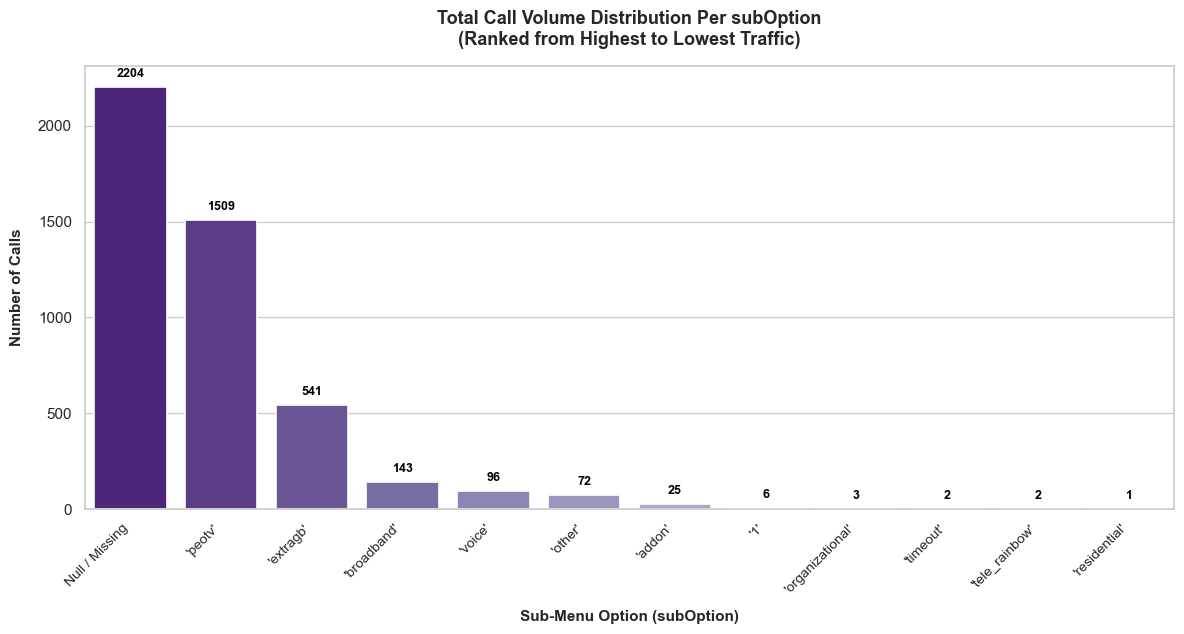

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate call counts for each subOption (including Null/Missing values)
sub_counts = df['subOption'].value_counts(dropna=False).reset_index()
sub_counts.columns = ['subOption', 'call_count']

# 2. Format clean text labels for the X-axis bars
sub_counts['Option_Label'] = sub_counts['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# 3. Sort the dataframe from the highest call count volume to the lowest
sub_counts = sub_counts.sort_values(by='call_count', ascending=False)

# 4. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.5))

# Use the 'Purples_r' palette to give a clean descending gradient from highest to lowest volume
sns.barplot(
    data=sub_counts,
    x='Option_Label',
    y='call_count',
    palette='Purples_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 5. Add the exact call count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels
ax.set_title("Total Call Volume Distribution Per subOption\n(Ranked from Highest to Lowest Traffic)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Sub-Menu Option (subOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Calls", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels to accommodate longer sub-option names without overlapping text lines
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Save the high-resolution figure directly to your directory path
plt.savefig('sub_options_ranked_volume.png', dpi=300)

  Elsie Terminal Tracker: Calls with Queue Time > 0
👑 HIGHEST ➔ Option 2: 477 calls
🔹 Option 7: 116 calls
🔹 Option 3: 89 calls
🔹 Option 1: 71 calls
🔹 Option 4: 22 calls
🔹 Null / Missing: 5 calls
🔹 Option 6: 1 calls
🔹 Option 5: 1 calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\1176566050.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


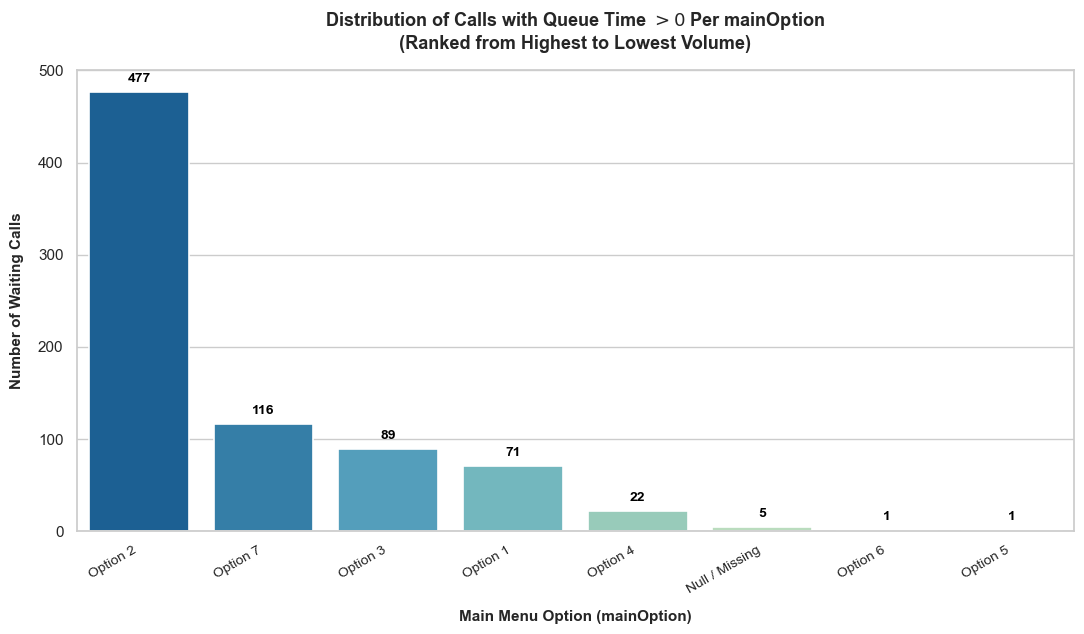

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Maintain consistency by combining mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Filter the dataset for calls that spent more than 0 seconds in the queue
queue_waiting_df = df[df['queue_time'] > 0]

# 3. Calculate the call counts for each mainOption group (including Nulls)
counts_df = queue_waiting_df['mainOption'].value_counts(dropna=False).reset_index()
counts_df.columns = ['mainOption', 'call_count']

# Create clean string text labels for the options
counts_df['Option_Label'] = counts_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# Force sorting order from highest call volume to lowest
counts_df = counts_df.sort_values(by='call_count', ascending=False)

# 4. Print out the ranked text leaderboard row-by-row
print("================================================================")
print("  Elsie Terminal Tracker: Calls with Queue Time > 0")
print("================================================================")
for index, row in counts_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {row['call_count']} calls")
print("================================================================")


# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a descending green-to-blue gradient to highlight the highest volume groups
sns.barplot(
    data=counts_df,
    x='Option_Label',
    y='call_count',
    palette='GnBu_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# Add exact call count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis labels using clear mathematical notations
ax.set_title("Distribution of Calls with Queue Time $> 0$ Per mainOption\n(Ranked from Highest to Lowest Volume)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Waiting Calls", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to guarantee no text crowding or overlap truncation
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('queue_time_greater_than_0_ranked.png', dpi=300)
plt.show()

 📊 TOTAL CALLS WITH QUEUE TIME > 0 PER subOption
👑 HIGHEST ➔ 'peotv': 393 calls
🔹 Null / Missing: 281 calls
🔹 'broadband': 46 calls
🔹 'other': 23 calls
🔹 'extragb': 22 calls
🔹 'voice': 15 calls
🔹 '1': 1 calls
🔹 'residential': 1 calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\3063871479.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


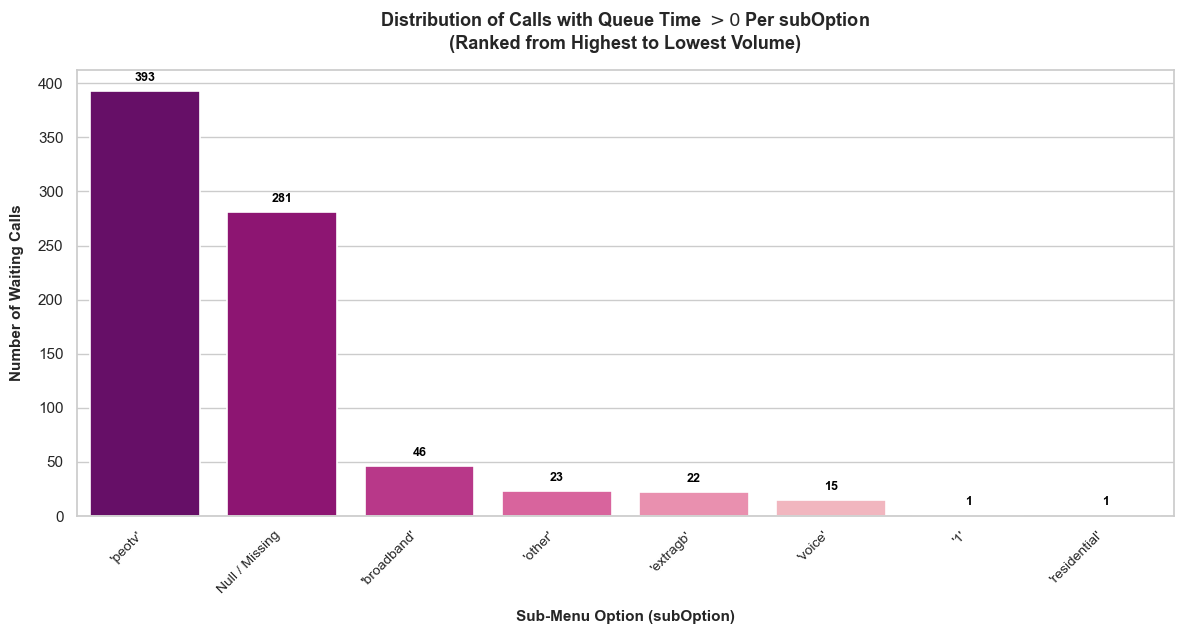

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset for calls that spent more than 0 seconds in the queue
queue_waiting_df = df[df['queue_time'] > 0]

# 2. Calculate the call counts for each subOption group (including Nulls)
# value_counts automatically handles descending sorting order
sub_counts = queue_waiting_df['subOption'].value_counts(dropna=False).reset_index()
sub_counts.columns = ['subOption', 'call_count']

# Create clean string text labels for the X-axis bars
sub_counts['Option_Label'] = sub_counts['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# Force the sorting layout explicitly from highest call volume to lowest
sub_counts = sub_counts.sort_values(by='call_count', ascending=False)

# 3. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" 📊 TOTAL CALLS WITH QUEUE TIME > 0 PER subOption")
print("================================================================")
for index, row in sub_counts.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {row['call_count']} calls")
print("================================================================")


# 4. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.5))

# Use a descending purple/pink gradient palette to visualize the traffic drop-off
sns.barplot(
    data=sub_counts,
    x='Option_Label',
    y='call_count',
    palette='RdPu_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 5. Add exact numeric value callouts dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean math formatting
ax.set_title("Distribution of Calls with Queue Time $> 0$ Per subOption\n(Ranked from Highest to Lowest Volume)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Sub-Menu Option (subOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Waiting Calls", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to accommodate longer sub-option names without text crowding
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('sub_options_queue_greater_than_0.png', dpi=300)

  📊 TOTAL ANSWERED CALLS PER mainOption (HIGHEST TO LOWEST)
👑 HIGHEST ➔ Option 2: 479 answered calls
🔹 Option 7: 119 answered calls
🔹 Option 3: 89 answered calls
🔹 Option 1: 71 answered calls
🔹 Option 4: 22 answered calls
🔹 Null / Missing: 5 answered calls
🔹 Option 6: 1 answered calls
🔹 Option 5: 1 answered calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\2305551008.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


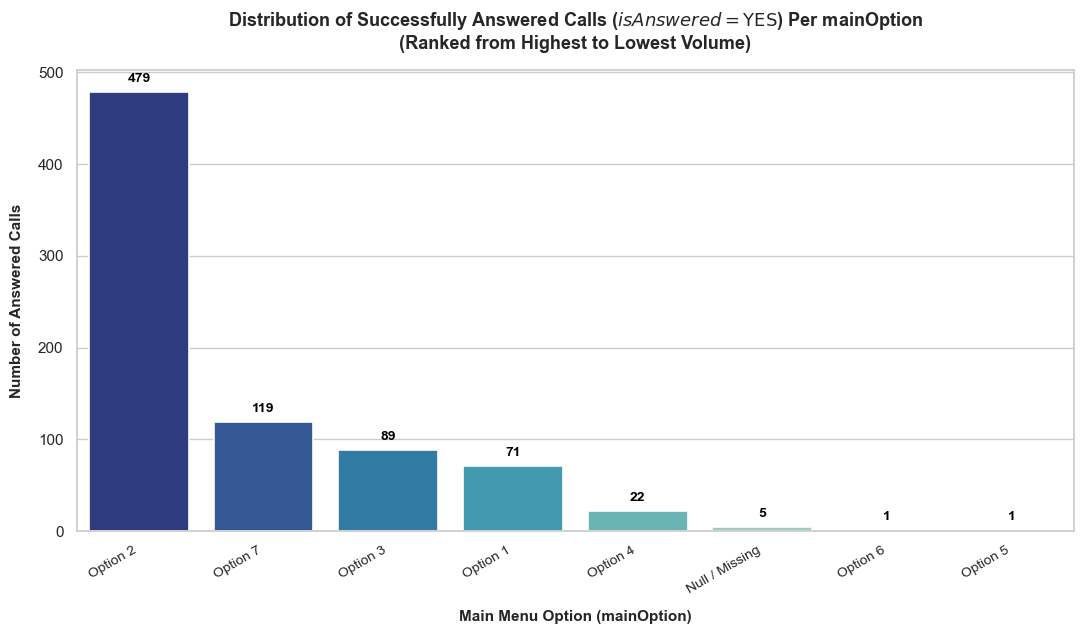

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Maintain consistency by combining mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Filter the dataset for calls that were successfully answered by an agent
answered_calls_df = df[df['isAnswered'] == 'YES']

# 3. Calculate the answered call counts for each mainOption group (including Nulls)
# value_counts automatically handles descending sorting order
counts_df = answered_calls_df['mainOption'].value_counts(dropna=False).reset_index()
counts_df.columns = ['mainOption', 'call_count']

# Create clean string text labels for the options
counts_df['Option_Label'] = counts_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# Force sorting order explicitly from highest answered volume to lowest
counts_df = counts_df.sort_values(by='call_count', ascending=False)

# 4. Print out the ranked text leaderboard row-by-row
print("================================================================")
print("  📊 TOTAL ANSWERED CALLS PER mainOption (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in counts_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {row['call_count']} answered calls")
print("================================================================")


# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a descending blue-to-green gradient palette to visualize the traffic drop-off
sns.barplot(
    data=counts_df,
    x='Option_Label',
    y='call_count',
    palette='YlGnBu_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# Add exact answered call count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Distribution of Successfully Answered Calls ($isAnswered = \\text{YES}$) Per mainOption\n(Ranked from Highest to Lowest Volume)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Answered Calls", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to guarantee no text crowding or overlap truncation
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('answered_calls_by_mainoption_ranked.png', dpi=300)
plt.show()

  📊 TOTAL ANSWERED CALLS PER subOption (HIGHEST TO LOWEST)
👑 HIGHEST ➔ 'peotv': 393 answered calls
🔹 Null / Missing: 284 answered calls
🔹 'broadband': 48 answered calls
🔹 'other': 23 answered calls
🔹 'extragb': 22 answered calls
🔹 'voice': 15 answered calls
🔹 '1': 1 answered calls
🔹 'residential': 1 answered calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\1726843003.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


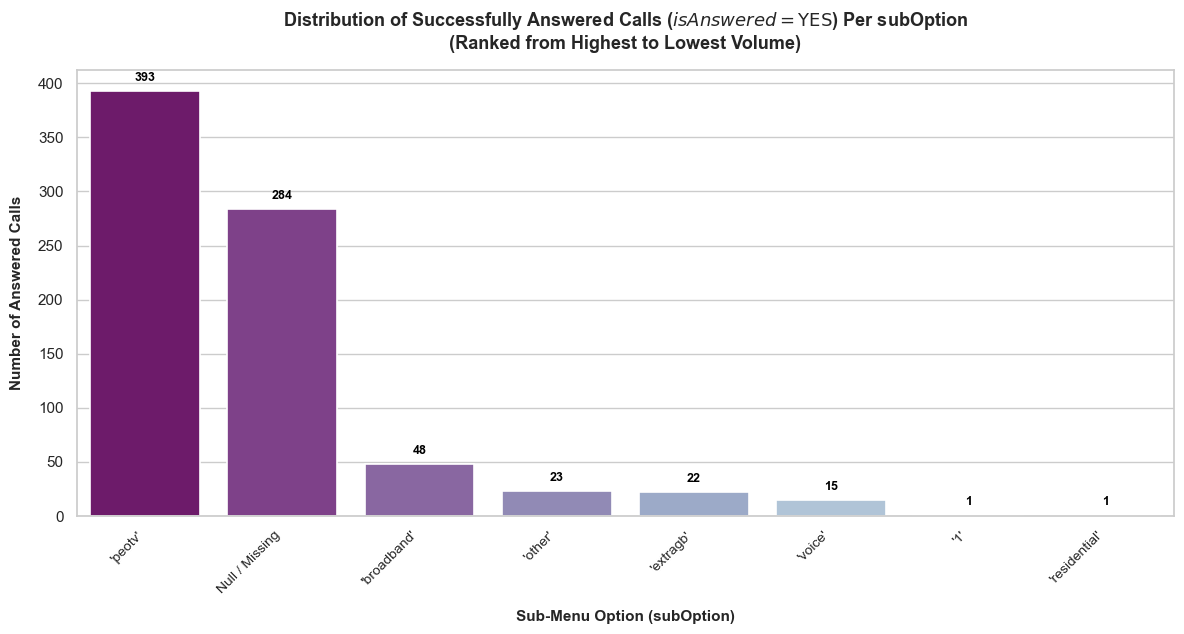

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset for calls that were successfully answered by an agent
answered_calls_df = df[df['isAnswered'] == 'YES']

# 2. Calculate the answered call counts for each subOption group (including Nulls)
# value_counts automatically handles descending sorting order
sub_counts = answered_calls_df['subOption'].value_counts(dropna=False).reset_index()
sub_counts.columns = ['subOption', 'call_count']

# Create clean string text labels for the X-axis bars
sub_counts['Option_Label'] = sub_counts['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# Force sorting order explicitly from highest answered volume to lowest
sub_counts = sub_counts.sort_values(by='call_count', ascending=False)

# 3. Print out the ranked text leaderboard row-by-row
print("================================================================")
print("  📊 TOTAL ANSWERED CALLS PER subOption (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in sub_counts.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {row['call_count']} answered calls")
print("================================================================")


# 4. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.5))

# Use a descending reddish-purple gradient palette to visualize the traffic drop-off
sns.barplot(
    data=sub_counts,
    x='Option_Label',
    y='call_count',
    palette='BuPu_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 5. Add exact answered call count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Distribution of Successfully Answered Calls ($isAnswered = \\text{YES}$) Per subOption\n(Ranked from Highest to Lowest Volume)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Sub-Menu Option (subOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of Answered Calls", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to accommodate longer sub-option names without text crowding
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('answered_calls_by_suboption_ranked.png', dpi=300)
plt.show()

 ⏱️ MAXIMUM TALK TIME PER mainOption (HIGHEST TO LOWEST)
👑 HIGHEST ➔ Option 2: 868s (14m 28s)
🔹 Option 7: 792s (13m 12s)
🔹 Option 3: 596s (9m 56s)
🔹 Option 1: 501s (8m 21s)
🔹 Option 4: 478s (7m 58s)
🔹 Null / Missing: 369s (6m 9s)
🔹 Option 6: 249s (4m 9s)
🔹 Option 5: 44s


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\2926612887.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


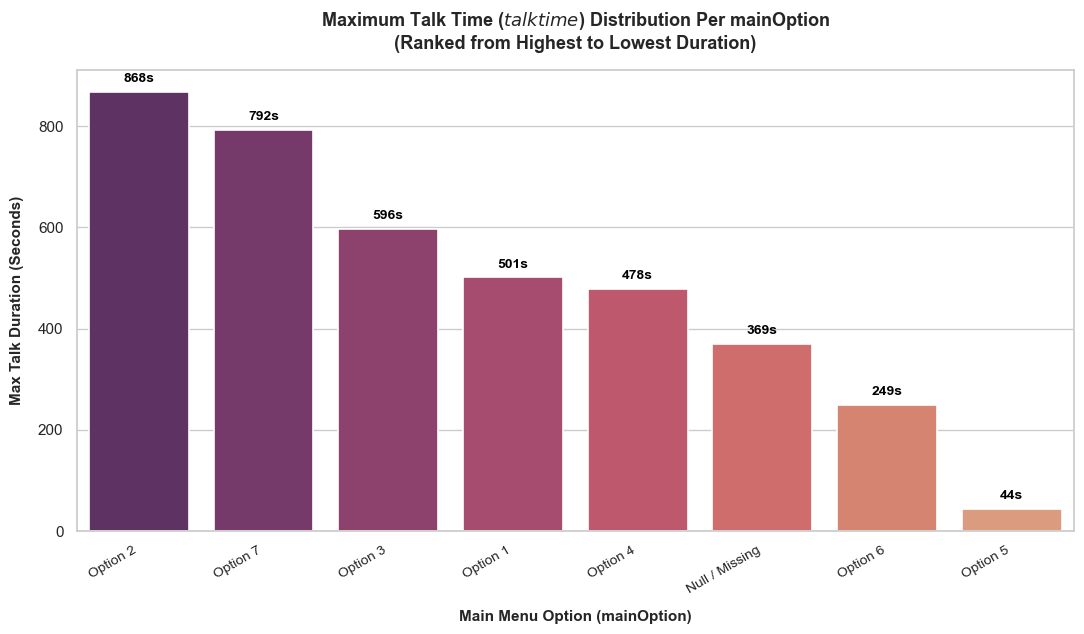

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Maintain consistency by combining mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Clean talk_time column to ensure absolute integer validation
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 3. Calculate the maximum talk time for each mainOption group (including Nulls)
max_talk_df = df.groupby('mainOption', dropna=False)['talk_time'].max().reset_index()
max_talk_df.columns = ['mainOption', 'max_talk_time']

# Create clean string text x-axis labels for the options
max_talk_df['Option_Label'] = max_talk_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# Force the sorting layout explicitly from highest talk time to lowest
max_talk_df = max_talk_df.sort_values(by='max_talk_time', ascending=False).reset_index(drop=True)

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 4. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" ⏱️ MAXIMUM TALK TIME PER mainOption (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in max_talk_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {format_to_minutes(row['max_talk_time'])}")
print("================================================================")


# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a warm, descending magma-based gradient palette to highlight the top durations
sns.barplot(
    data=max_talk_df,
    x='Option_Label',
    y='max_talk_time',
    palette='flare_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Add the exact talk time digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}s", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Maximum Talk Time ($talktime$) Distribution Per mainOption\n(Ranked from Highest to Lowest Duration)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Max Talk Duration (Seconds)", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to guarantee no text crowding or overlap truncation
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('max_talk_time_by_mainoption_ranked.png', dpi=300)
plt.show()

 ⏱️ MAXIMUM TALK TIME PER subOption (HIGHEST TO LOWEST)
👑 HIGHEST ➔ 'peotv': 868s (14m 28s)
🔹 Null / Missing: 792s (13m 12s)
🔹 'broadband': 662s (11m 2s)
🔹 'extragb': 478s (7m 58s)
🔹 'other': 308s (5m 8s)
🔹 '1': 249s (4m 9s)
🔹 'voice': 179s (2m 59s)
🔹 'residential': 44s
🔹 'addon': 0s
🔹 'organizational': 0s
🔹 'timeout': 0s
🔹 'tele_rainbow': 0s


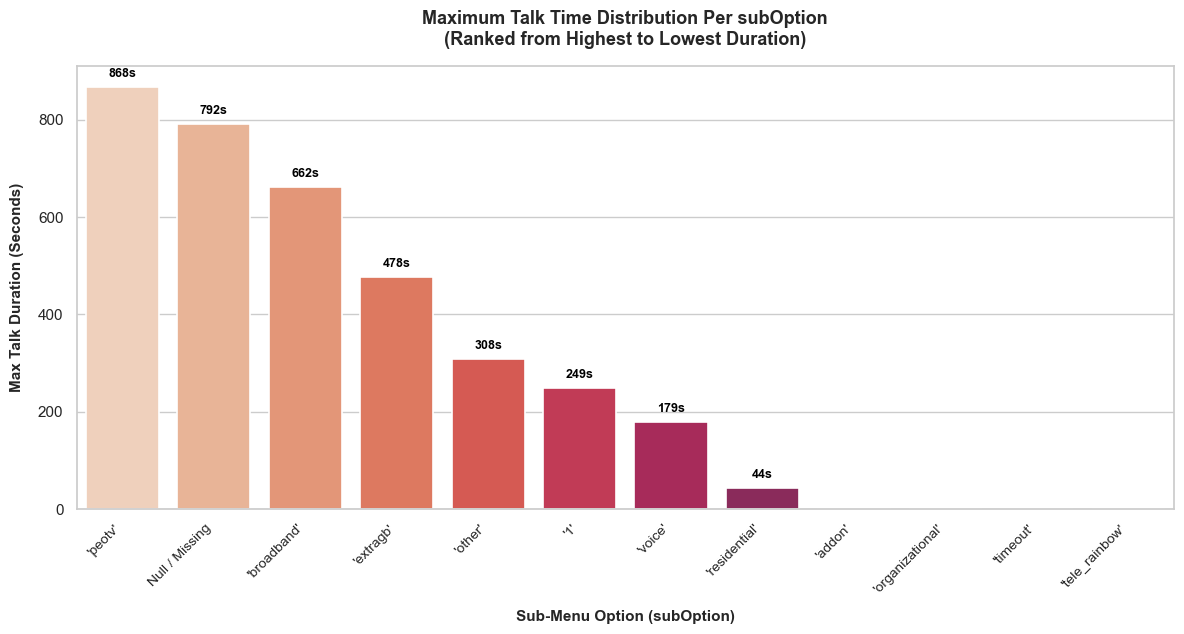

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean talk_time column to ensure absolute integer validation
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Calculate the maximum talk time for each subOption group (including Nulls)
max_talk_sub_df = df.groupby('subOption', dropna=False)['talk_time'].max().reset_index()
max_talk_sub_df.columns = ['subOption', 'max_talk_time']

# Create clean string text labels for the x-axis
max_talk_sub_df['Option_Label'] = max_talk_sub_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# Force the sorting layout explicitly from highest talk time to lowest
max_talk_sub_df = max_talk_sub_df.sort_values(by='max_talk_time', ascending=False).reset_index(drop=True)

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 3. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" ⏱️ MAXIMUM TALK TIME PER subOption (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in max_talk_sub_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {format_to_minutes(row['max_talk_time'])}")
print("================================================================")


# 4. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.5))

# Use a warm, descending gradient palette to highlight the top durations
sns.barplot(
    data=max_talk_sub_df,
    x='Option_Label',
    y='max_talk_time',
    hue='Option_Label',
    palette='rocket_r',  
    legend=False,
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 5. Add the exact talk time digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}s", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Maximum Talk Time Distribution Per subOption\n(Ranked from Highest to Lowest Duration)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Sub-Menu Option (subOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Max Talk Duration (Seconds)", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to guarantee no text crowding or overlap truncation
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('max_talk_time_by_suboption_ranked.png', dpi=300)
plt.show()

 ⏱️ MAXIMUM TOTAL TIME PER mainOption (HIGHEST TO LOWEST)
👑 HIGHEST ➔ Option 2: 1688s (28m 8s)
🔹 Option 7: 1680s (28m 0s)
🔹 Option 3: 1530s (25m 30s)
🔹 Option 4: 1352s (22m 32s)
🔹 Null / Missing: 1324s (22m 4s)
🔹 Option 1: 1291s (21m 31s)
🔹 Option 6: 496s (8m 16s)
🔹 Option 5: 310s (5m 10s)


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\2482990380.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


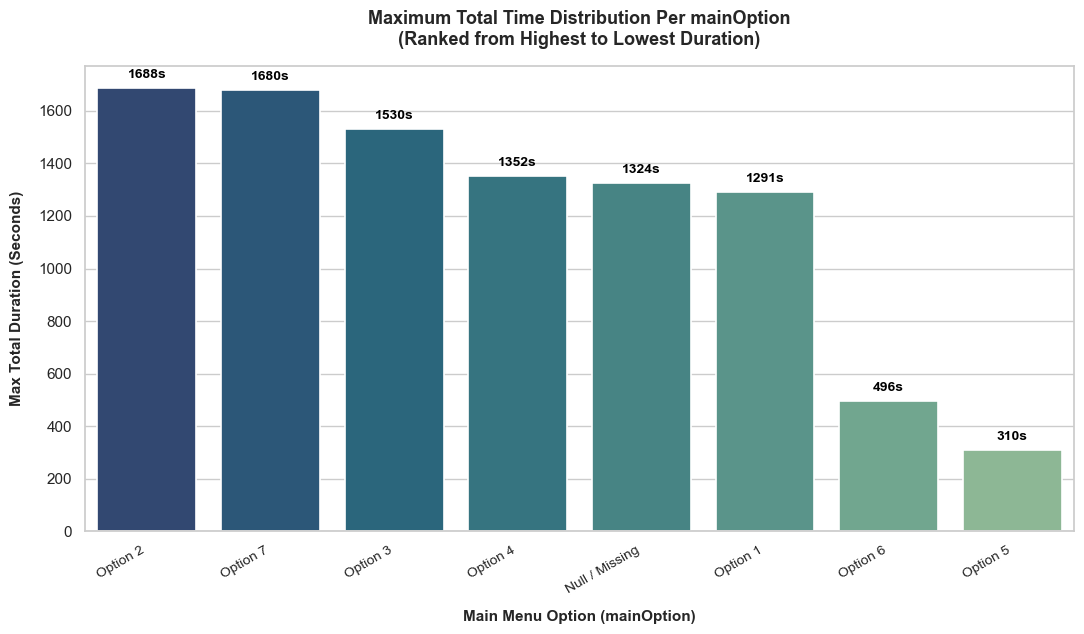

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Maintain consistency by combining mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Clean both duration columns to ensure absolute integer validation
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 3. Calculate the Total Time for each call (Queue Time + Talk Time)
df['total_time'] = df['queue_time'] + df['talk_time']

# 4. Find the maximum total time for each mainOption group (including Nulls)
max_tot_df = df.groupby('mainOption', dropna=False)['total_time'].max().reset_index()
max_tot_df.columns = ['mainOption', 'max_total_time']

# Create clean string text x-axis labels for the options
max_tot_df['Option_Label'] = max_tot_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# Force the sorting layout explicitly from highest total time to lowest
max_tot_df = max_tot_df.sort_values(by='max_total_time', ascending=False).reset_index(drop=True)

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 5. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" ⏱️ MAXIMUM TOTAL TIME PER mainOption (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in max_tot_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {format_to_minutes(row['max_total_time'])}")
print("================================================================")


# 6. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a clean, descending cool-to-warm gradient palette to highlight the top durations
sns.barplot(
    data=max_tot_df,
    x='Option_Label',
    y='max_total_time',
    palette='crest_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 7. Add the exact total time digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}s", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Maximum Total Time Distribution Per mainOption\n(Ranked from Highest to Lowest Duration)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Max Total Duration (Seconds)", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to guarantee no text crowding or overlap truncation
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('max_total_time_by_mainoption_ranked.png', dpi=300)
plt.show()

 ⏱️ MAXIMUM TOTAL TIME PER subOption (HIGHEST TO LOWEST)
👑 HIGHEST ➔ 'peotv': 1688s (28m 8s)
🔹 Null / Missing: 1680s (28m 0s)
🔹 'extragb': 1352s (22m 32s)
🔹 'other': 1269s (21m 9s)
🔹 'broadband': 1232s (20m 32s)
🔹 'voice': 1033s (17m 13s)
🔹 '1': 496s (8m 16s)
🔹 'residential': 310s (5m 10s)
🔹 'addon': 0s
🔹 'organizational': 0s
🔹 'timeout': 0s
🔹 'tele_rainbow': 0s


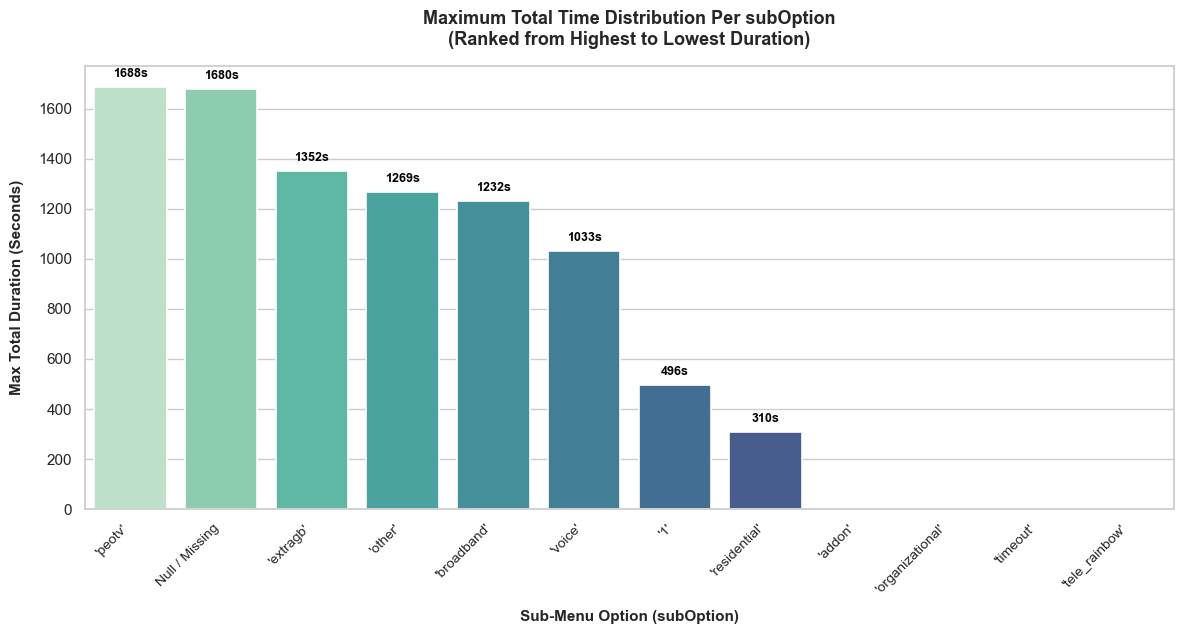

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean both duration columns to ensure absolute integer validation
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Calculate the Total Time for each call (Queue Time + Talk Time)
df['total_time'] = df['queue_time'] + df['talk_time']

# 3. Find the maximum total time for each subOption group (including Nulls)
max_tot_sub_df = df.groupby('subOption', dropna=False)['total_time'].max().reset_index()
max_tot_sub_df.columns = ['subOption', 'max_total_time']

# Create clean string text labels for the x-axis
max_tot_sub_df['Option_Label'] = max_tot_sub_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# Force the sorting layout explicitly from highest total time to lowest
max_tot_sub_df = max_tot_sub_df.sort_values(by='max_total_time', ascending=False).reset_index(drop=True)

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 4. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" ⏱️ MAXIMUM TOTAL TIME PER subOption (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in max_tot_sub_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Option_Label']}: {format_to_minutes(row['max_total_time'])}")
print("================================================================")


# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.5))

# Use a clean, descending cool-to-warm gradient palette to highlight the top durations
sns.barplot(
    data=max_tot_sub_df,
    x='Option_Label',
    y='max_total_time',
    hue='Option_Label',
    palette='mako_r',  
    legend=False,
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Add the exact total time digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}s", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Maximum Total Time Distribution Per subOption\n(Ranked from Highest to Lowest Duration)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Sub-Menu Option (subOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Max Total Duration (Seconds)", fontsize=11, fontweight='bold', labelpad=10)

# Rotate labels cleanly to guarantee no text crowding or overlap truncation
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('max_total_time_by_suboption_ranked.png', dpi=300)

  📊 TOTAL 'YES' COUNTS PER SERVICE STATUS (HIGHEST TO LOWEST)
👑 HIGHEST ➔ suspendedAsset: 645 calls
🔹 extraGBAdded: 279 calls
🔹 existingFault: 131 calls
🔹 dataLimitExceed: 51 calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\3445782427.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


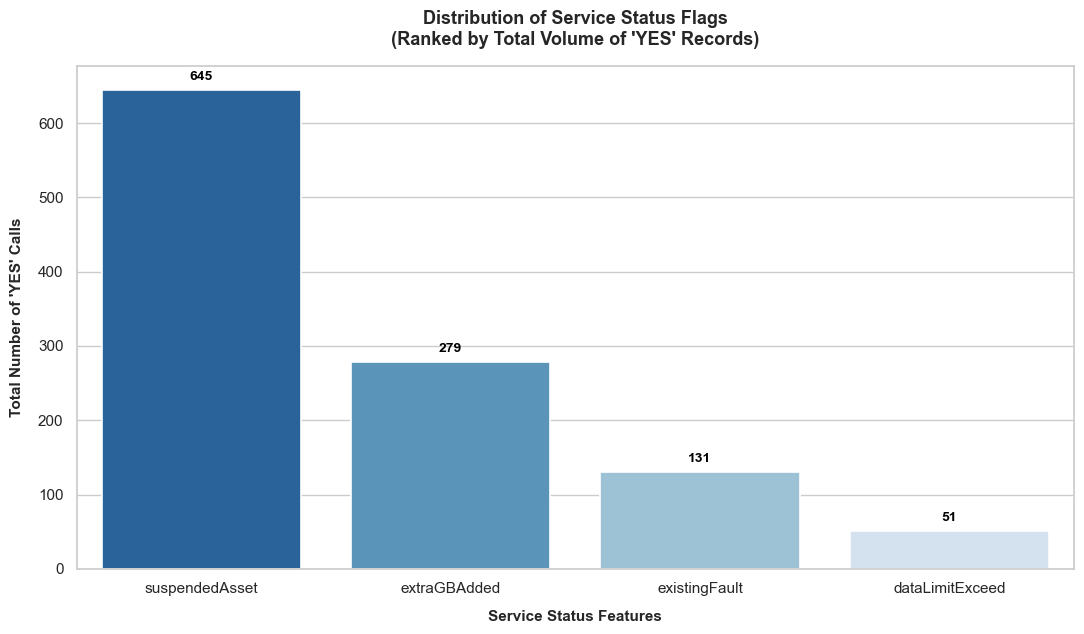

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the four service status features to evaluate
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# 2. Count the number of 'YES' records for each feature
yes_counts = {}
for feature in status_features:
    # Ensure the column exists and count rows matching 'YES'
    if feature in df.columns:
        yes_counts[feature] = (df[feature] == 'YES').sum()
    else:
        yes_counts[feature] = 0

# 3. Convert the counts into a DataFrame and sort from highest to lowest
counts_df = pd.DataFrame(list(yes_counts.items()), columns=['Service_Status', 'Yes_Count'])
counts_df = counts_df.sort_values(by='Yes_Count', ascending=False).reset_index(drop=True)

# 4. Print out the ranked text leaderboard row-by-row
print("================================================================")
print("  📊 TOTAL 'YES' COUNTS PER SERVICE STATUS (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in counts_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Service_Status']}: {row['Yes_Count']} calls")
print("================================================================")


# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a clean, descending cool-toned gradient palette to highlight the top features
sns.barplot(
    data=counts_df,
    x='Service_Status',
    y='Yes_Count',
    palette='Blues_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Add the exact count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height >= 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels
ax.set_title("Distribution of Service Status Flags\n(Ranked by Total Volume of 'YES' Records)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Service Status Features", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Total Number of 'YES' Calls", fontsize=11, fontweight='bold', labelpad=10)

# Clean layout spacing to guarantee no text crowding or overlap truncation
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('service_status_yes_counts_ranked.png', dpi=300)

 📊 SERVICE FLAGS FOR CALLS WITH QUEUE TIME > 0 (HIGH TO LOW)
👑 HIGHEST ➔ suspendedAsset: 183 calls
🔹 existingFault: 38 calls
🔹 dataLimitExceed: 15 calls
🔹 extraGBAdded: 0 calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\1165562191.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


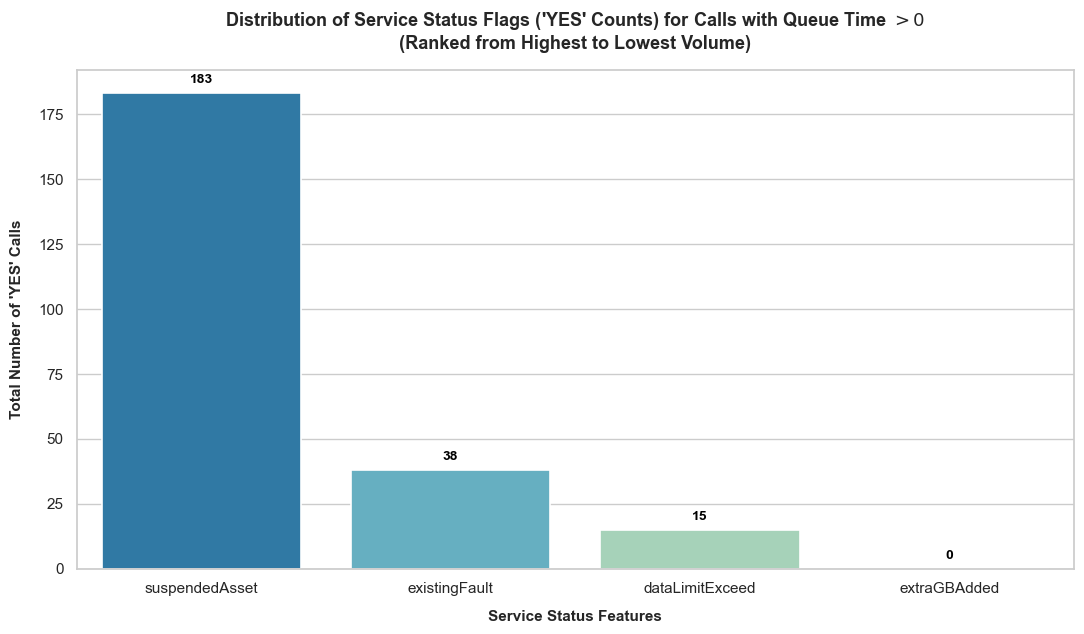

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure duration columns are properly converted and cleaned
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)

# 2. Filter the dataset strictly for calls that spent more than 0 seconds in the queue
queue_waiting_df = df[df['queue_time'] > 0]

# 3. Define the four service status features to evaluate
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# 4. Count the number of 'YES' records for each feature within the waiting subset
yes_counts = {}
for feature in status_features:
    if feature in queue_waiting_df.columns:
        yes_counts[feature] = (queue_waiting_df[feature] == 'YES').sum()
    else:
        yes_counts[feature] = 0

# Convert the counts into a DataFrame and sort from highest to lowest volume
counts_df = pd.DataFrame(list(yes_counts.items()), columns=['Service_Status', 'Yes_Count'])
counts_df = counts_df.sort_values(by='Yes_Count', ascending=False).reset_index(drop=True)

# 5. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" 📊 SERVICE FLAGS FOR CALLS WITH QUEUE TIME > 0 (HIGH TO LOW)")
print("================================================================")
for index, row in counts_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Service_Status']}: {row['Yes_Count']} calls")
print("================================================================")


# 6. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a descending green/teal-toned gradient palette to highlight the top features
sns.barplot(
    data=counts_df,
    x='Service_Status',
    y='Yes_Count',
    palette='GnBu_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 7. Add the exact count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height >= 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using standard math formatting
ax.set_title("Distribution of Service Status Flags ('YES' Counts) for Calls with Queue Time $> 0$\n(Ranked from Highest to Lowest Volume)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Service Status Features", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Total Number of 'YES' Calls", fontsize=11, fontweight='bold', labelpad=10)

# Clean layout spacing to guarantee no text crowding or overlap truncation
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('service_status_queue_greater_than_0_ranked.png', dpi=300)
plt.show()

 📊 SERVICE FLAGS FOR SUCCESSFULLY ANSWERED CALLS (HIGH TO LOW)
👑 HIGHEST ➔ suspendedAsset: 183 answered calls
🔹 existingFault: 38 answered calls
🔹 dataLimitExceed: 16 answered calls
🔹 extraGBAdded: 0 answered calls


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\1179278151.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


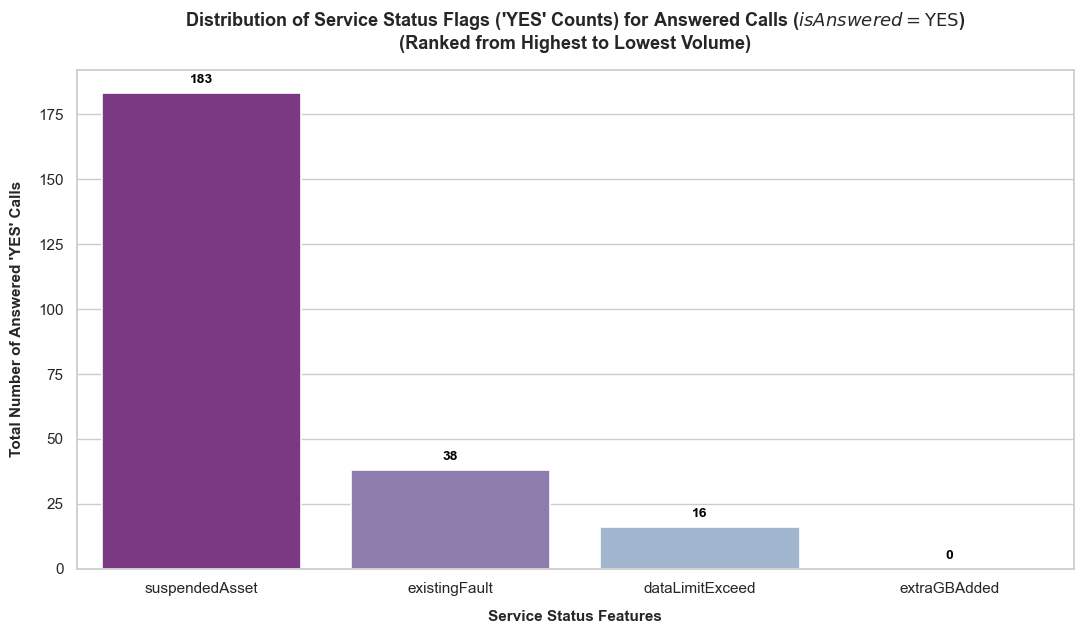

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset strictly for calls that were successfully answered by an agent
answered_calls_df = df[df['isAnswered'] == 'YES']

# 2. Define the four service status features to evaluate
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# 3. Count the number of 'YES' records for each feature within the answered subset
yes_counts = {}
for feature in status_features:
    if feature in answered_calls_df.columns:
        yes_counts[feature] = (answered_calls_df[feature] == 'YES').sum()
    else:
        yes_counts[feature] = 0

# Convert the counts into a DataFrame and sort from highest to lowest volume
counts_df = pd.DataFrame(list(yes_counts.items()), columns=['Service_Status', 'Yes_Count'])
counts_df = counts_df.sort_values(by='Yes_Count', ascending=False).reset_index(drop=True)

# 4. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" 📊 SERVICE FLAGS FOR SUCCESSFULLY ANSWERED CALLS (HIGH TO LOW)")
print("================================================================")
for index, row in counts_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Service_Status']}: {row['Yes_Count']} answered calls")
print("================================================================")


# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a descending purple-to-blue gradient palette to highlight the top features
sns.barplot(
    data=counts_df,
    x='Service_Status',
    y='Yes_Count',
    palette='BuPu_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Add the exact count digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height >= 0:
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Distribution of Service Status Flags ('YES' Counts) for Answered Calls ($isAnswered = \\text{YES}$)\n(Ranked from Highest to Lowest Volume)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Service Status Features", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Total Number of Answered 'YES' Calls", fontsize=11, fontweight='bold', labelpad=10)

# Clean layout spacing to guarantee no text crowding or overlap truncation
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('service_status_answered_ranked.png', dpi=300)
plt.show()

 ⏱️ MAXIMUM TALK TIME PER SERVICE STATUS (HIGHEST TO LOWEST)
👑 HIGHEST ➔ suspendedAsset: 625s (10m 25s)
🔹 existingFault: 536s (8m 56s)
🔹 dataLimitExceed: 282s (4m 42s)
🔹 extraGBAdded: 0s


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\1507118972.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


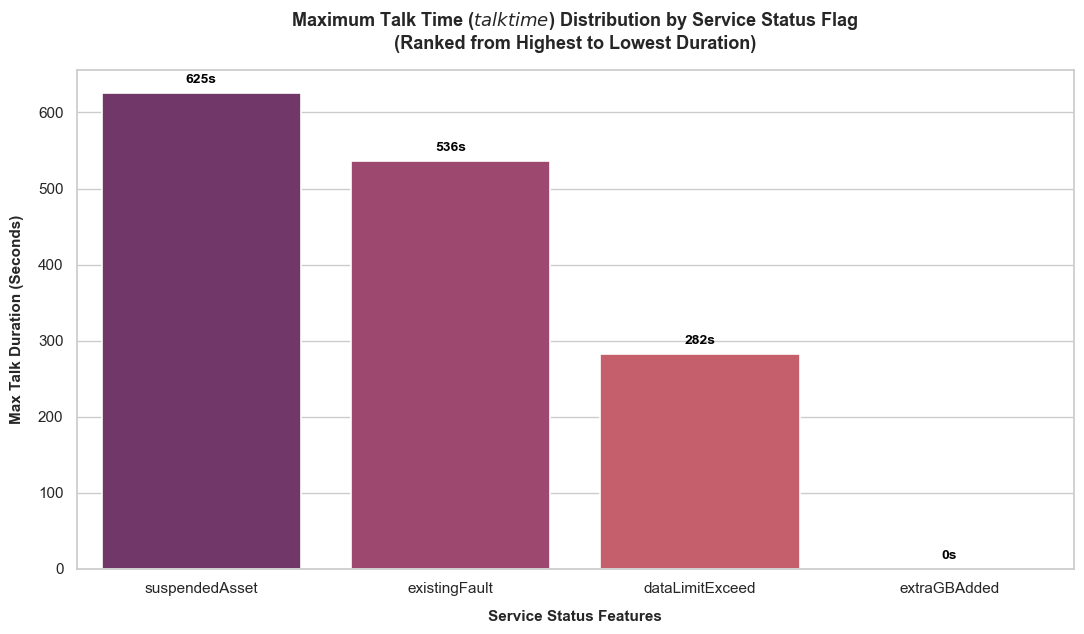

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean talk_time column to ensure absolute integer validation
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Define the four service status features to evaluate
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# 3. Calculate the maximum talk time for each feature when it is 'YES'
max_talk_times = {}
for feature in status_features:
    if feature in df.columns:
        # Filter rows where this specific flag is 'YES'
        yes_subset = df[df[feature] == 'YES']
        if not yes_subset.empty:
            max_talk_times[feature] = yes_subset['talk_time'].max()
        else:
            max_talk_times[feature] = 0
    else:
        max_talk_times[feature] = 0

# Convert the results into a DataFrame and sort from highest to lowest duration
max_talk_df = pd.DataFrame(list(max_talk_times.items()), columns=['Service_Status', 'Max_Talk_Time'])
max_talk_df = max_talk_df.sort_values(by='Max_Talk_Time', ascending=False).reset_index(drop=True)

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 4. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" ⏱️ MAXIMUM TALK TIME PER SERVICE STATUS (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in max_talk_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Service_Status']}: {format_to_minutes(row['Max_Talk_Time'])}")
print("================================================================")


# 5. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a warm, descending gradient palette to highlight the top durations
sns.barplot(
    data=max_talk_df,
    x='Service_Status',
    y='Max_Talk_Time',
    palette='flare_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 6. Add the exact talk time digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height >= 0:
        ax.annotate(
            f"{int(height)}s", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Maximum Talk Time ($talktime$) Distribution by Service Status Flag\n(Ranked from Highest to Lowest Duration)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Service Status Features", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Max Talk Duration (Seconds)", fontsize=11, fontweight='bold', labelpad=10)

# Clean layout spacing to guarantee no text crowding or overlap truncation
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('service_status_max_talk_time_ranked.png', dpi=300)
plt.show()

 ⏱️ MAXIMUM TOTAL TIME PER SERVICE STATUS (HIGHEST TO LOWEST)
👑 HIGHEST ➔ suspendedAsset: 1655s (27m 35s)
🔹 existingFault: 1369s (22m 49s)
🔹 dataLimitExceed: 1211s (20m 11s)
🔹 extraGBAdded: 0s


C:\Users\Mihiliya Jayasiri\AppData\Local\Temp\ipykernel_45784\389191562.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


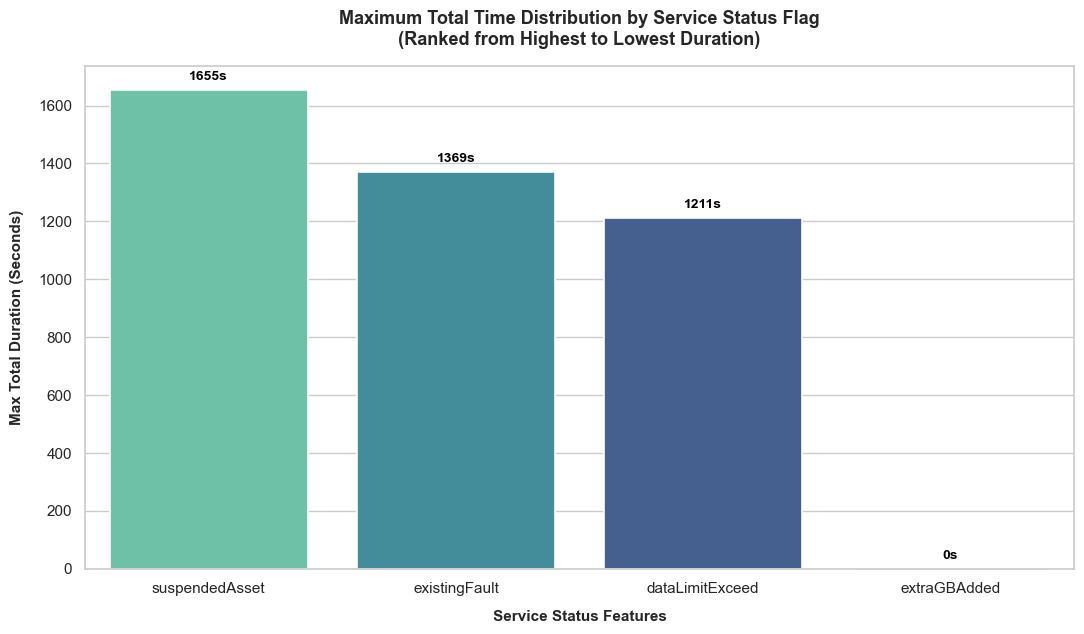

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean both duration columns to ensure absolute integer validation
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce').fillna(0).astype(int)
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce').fillna(0).astype(int)

# 2. Calculate the Total Time for each call (Queue Time + Talk Time)
df['total_time'] = df['queue_time'] + df['talk_time']

# 3. Define the four service status features to evaluate
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# 4. Calculate the maximum total time for each feature when it is 'YES'
max_tot_times = {}
for feature in status_features:
    if feature in df.columns:
        # Filter rows where this specific flag is 'YES'
        yes_subset = df[df[feature] == 'YES']
        if not yes_subset.empty:
            max_tot_times[feature] = yes_subset['total_time'].max()
        else:
            max_tot_times[feature] = 0
    else:
        max_tot_times[feature] = 0

# Convert the results into a DataFrame and sort from highest to lowest duration
max_tot_df = pd.DataFrame(list(max_tot_times.items()), columns=['Service_Status', 'Max_Total_Time'])
max_tot_df = max_tot_df.sort_values(by='Max_Total_Time', ascending=False).reset_index(drop=True)

# Helper function to convert raw seconds to a readable 'Xs (Ym Zs)' format
def format_to_minutes(seconds):
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    if minutes > 0:
        return f"{seconds}s ({minutes}m {remaining_seconds}s)"
    return f"{seconds}s"

# 5. Print out the ranked text leaderboard row-by-row
print("================================================================")
print(" ⏱️ MAXIMUM TOTAL TIME PER SERVICE STATUS (HIGHEST TO LOWEST)")
print("================================================================")
for index, row in max_tot_df.iterrows():
    rank_prefix = "👑 HIGHEST ➔" if index == 0 else "🔹"
    print(f"{rank_prefix} {row['Service_Status']}: {format_to_minutes(row['Max_Total_Time'])}")
print("================================================================")


# 6. Generate the Bar Chart Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6.5))

# Use a clean, descending cool-to-warm gradient palette to highlight the top durations
sns.barplot(
    data=max_tot_df,
    x='Service_Status',
    y='Max_Total_Time',
    palette='mako_r',  
    ax=ax,
    edgecolor='white',
    linewidth=1.2
)

# 7. Add the exact total time digits dynamically on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height >= 0:
        ax.annotate(
            f"{int(height)}s", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            weight='bold',
            color='black',
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean formatting
ax.set_title("Maximum Total Time Distribution by Service Status Flag\n(Ranked from Highest to Lowest Duration)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Service Status Features", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Max Total Duration (Seconds)", fontsize=11, fontweight='bold', labelpad=10)

# Clean layout spacing to guarantee no text crowding or overlap truncation
plt.tight_layout()

# Save the plot high-resolution image locally to your working directory
plt.savefig('service_status_max_total_time_ranked.png', dpi=300)
plt.show()

 📊 SERVICE STATUS LAYERED MATRIX BREAKDOWN PER mainOption ('YES' COUNTS)
Service_Status  dataLimitExceed  existingFault  extraGBAdded  suspendedAsset
Option_Label                                                                
Option 2                     42            131             0             645
Option 4                      9              0           279               0


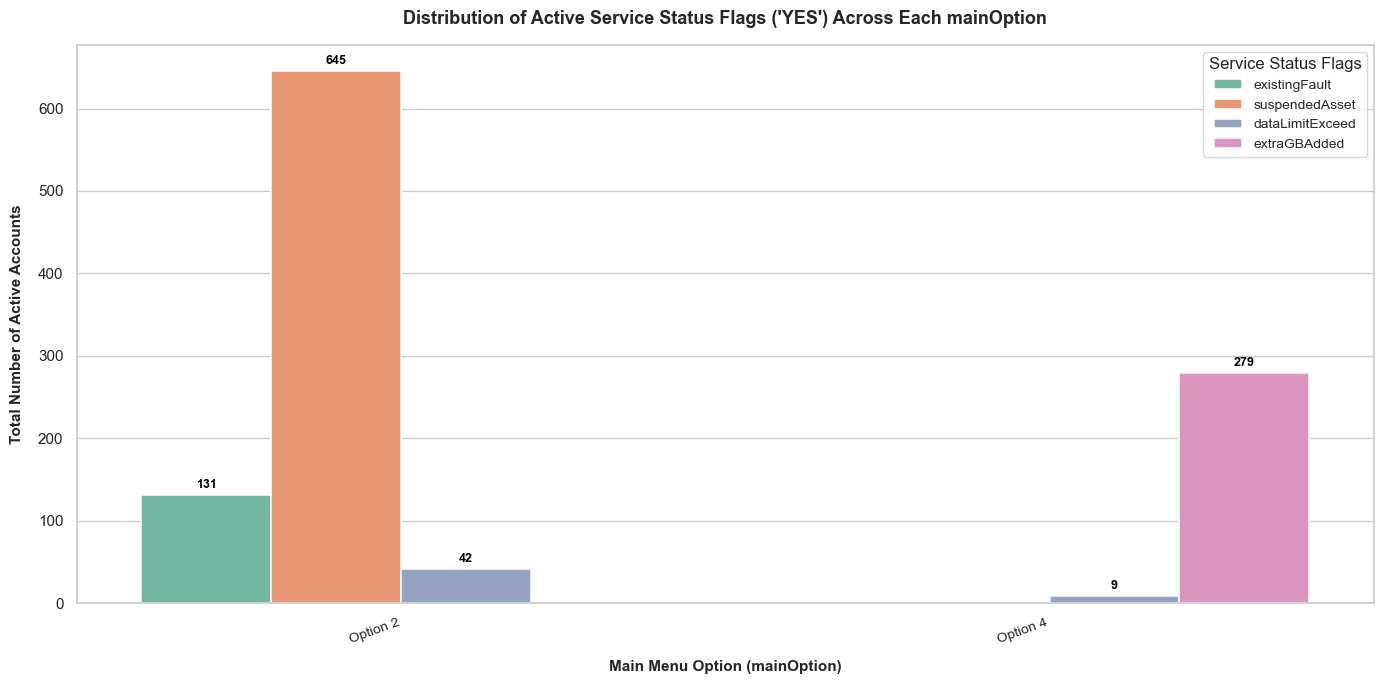

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Maintain previous adjustment: Combine mainOption 14.0 and 11.0 into 7.0
df['mainOption'] = df['mainOption'].replace({14.0: 7.0, 11.0: 7.0})

# 2. Define the four service status flags to track
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# 3. Build a consolidated matrix of 'YES' counts broken down by mainOption
matrix_data = []

for feature in status_features:
    if feature in df.columns:
        # Filter rows where the service flag is active ('YES') and group by mainOption
        yes_subset = df[df[feature] == 'YES']
        counts = yes_subset.groupby('mainOption', dropna=False).size().reset_index(name='Count')
        counts['Service_Status'] = feature
        matrix_data.append(counts)

# Combine results into a single structured DataFrame
if matrix_data:
    summary_df = pd.concat(matrix_data, ignore_index=True)
else:
    # Fallback structure if columns are completely empty or missing
    summary_df = pd.DataFrame(columns=['mainOption', 'Count', 'Service_Status'])

# 4. Clean X-axis text labels for mainOption presentation
summary_df['Option_Label'] = summary_df['mainOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"Option {int(x)}"
)

# Pivot data into a clean, human-readable table grid matrix
pivot_matrix = summary_df.pivot_table(
    index='Option_Label', 
    columns='Service_Status', 
    values='Count', 
    aggfunc='sum',
    fill_value=0
).astype(int)

# Re-order index rows so 'Null / Missing' remains at the bottom of the grid
x_order = sorted([idx for idx in pivot_matrix.index if idx != 'Null / Missing'])
if 'Null / Missing' in pivot_matrix.index:
    x_order.append('Null / Missing')
pivot_matrix = pivot_matrix.reindex(x_order)

# 5. Print out the structured summary table to the notebook terminal
print("========================================================================")
print(" 📊 SERVICE STATUS LAYERED MATRIX BREAKDOWN PER mainOption ('YES' COUNTS)")
print("========================================================================")
print(pivot_matrix.to_string())
print("========================================================================")


# 6. Generate a Grouped Bar Chart Visualization to compare metrics
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=summary_df,
    x='Option_Label',
    y='Count',
    hue='Service_Status',
    order=x_order,
    palette='Set2', # Clean categorical distinguishing palette color scheme
    ax=ax,
    edgecolor='white',
    linewidth=1.1
)

# Add numeric metric digits dynamically right on top of each corresponding bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only label bars that contain counts greater than 0
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold',
            color='black',
            xytext=(0, 3), 
            textcoords='offset points'
        )

# Customize title and axis labels
ax.set_title("Distribution of Active Service Status Flags ('YES') Across Each mainOption", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Main Menu Option (mainOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Total Number of Active Accounts", fontsize=11, fontweight='bold', labelpad=10)

# Position legend box cleanly
ax.legend(title="Service Status Flags", loc="upper right", frameon=True, fontsize=10)

# Clean layout spacing to guarantee no text crowding or overlap truncation
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.tight_layout()

# Save high-resolution plot asset locally
plt.savefig('service_status_vs_mainoptions_matrix.png', dpi=300)
plt.show()

 📊 SERVICE STATUS LAYERED MATRIX BREAKDOWN PER subOption ('YES' COUNTS)
Service_Status  dataLimitExceed  existingFault  extraGBAdded  suspendedAsset
Option_Label                                                                
'addon'                       9              0             4               0
'broadband'                  42             17             0              20
'extragb'                     0              0           275               0
'peotv'                       0             97             0             624
'voice'                       0             17             0               1


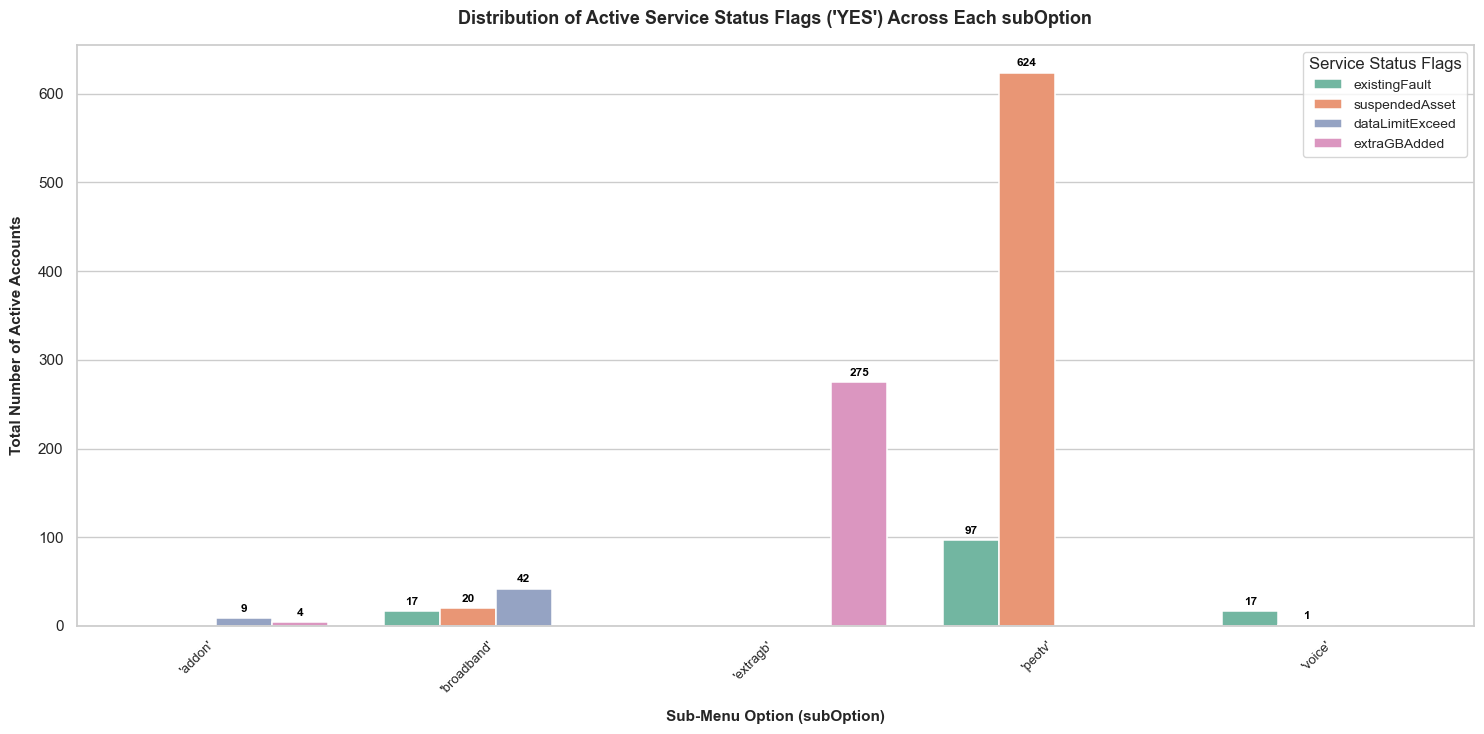

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean and define the four service status flags to evaluate
status_features = ["existingFault", "suspendedAsset", "dataLimitExceed", "extraGBAdded"]

# 2. Build a consolidated matrix of 'YES' counts broken down by subOption
matrix_data = []

for feature in status_features:
    if feature in df.columns:
        # Filter rows where the specific service status is active ('YES')
        yes_subset = df[df[feature] == 'YES']
        counts = yes_subset.groupby('subOption', dropna=False).size().reset_index(name='Count')
        counts['Service_Status'] = feature
        matrix_data.append(counts)

# Combine results into a single structured DataFrame
if matrix_data:
    summary_df = pd.concat(matrix_data, ignore_index=True)
else:
    summary_df = pd.DataFrame(columns=['subOption', 'Count', 'Service_Status'])

# 3. Process missing string inputs to keep 'Null / Missing' values visible
summary_df['Option_Label'] = summary_df['subOption'].apply(
    lambda x: 'Null / Missing' if pd.isnull(x) else f"'{x}'"
)

# Pivot data into a clean, human-readable table grid matrix
pivot_matrix = summary_df.pivot_table(
    index='Option_Label', 
    columns='Service_Status', 
    values='Count', 
    aggfunc='sum',
    fill_value=0
).astype(int)

# Re-order index rows so 'Null / Missing' remains at the absolute bottom of the grid
x_order = sorted([idx for idx in pivot_matrix.index if idx != 'Null / Missing'])
if 'Null / Missing' in pivot_matrix.index:
    x_order.append('Null / Missing')
pivot_matrix = pivot_matrix.reindex(x_order)

# 4. Print the cross-tabulation table to your notebook terminal
print("========================================================================")
print(" 📊 SERVICE STATUS LAYERED MATRIX BREAKDOWN PER subOption ('YES' COUNTS)")
print("========================================================================")
print(pivot_matrix.to_string())
print("========================================================================")


# 5. Generate a Grouped Bar Chart Visualization to compare metrics
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 7.5))

sns.barplot(
    data=summary_df,
    x='Option_Label',
    y='Count',
    hue='Service_Status',
    order=x_order,
    palette='Set2', # Highly distinguishable categorical palette
    ax=ax,
    edgecolor='white',
    linewidth=1.1
)

# 6. Add exact numeric metric digits dynamically right on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only display values for bars containing traffic counts
        ax.annotate(
            f"{int(height)}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=8.5, 
            weight='bold',
            color='black',
            xytext=(0, 3), 
            textcoords='offset points'
        )

# Customize title and axis text labels using clean typography
ax.set_title("Distribution of Active Service Status Flags ('YES') Across Each subOption", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Sub-Menu Option (subOption)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Total Number of Active Accounts", fontsize=11, fontweight='bold', labelpad=10)

# Position legend box cleanly
ax.legend(title="Service Status Flags", loc="upper right", frameon=True, fontsize=10)

# Rotate labels slightly to accommodate longer sub-option names perfectly
plt.xticks(rotation=45, ha='right', fontsize=9.5)
plt.tight_layout()

# Save the high-resolution visualization asset locally
plt.savefig('service_status_vs_suboptions_matrix.png', dpi=300)
plt.show()